<center><font size=10 color="navyblue">Advanced Machine Learning and MLOps</center></font>

<h1 style="text-align: center;">Tourism Package Prediction</h1>

---
## **Problem Statement**

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

###  **Business Context and Objective**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

---
## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


---
# Model Building


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

##  Folder Setup & Data Registration

### Folder Setup

```mk
    - Create a repo in github and clone to local machine 
    
    - Install Git: 
        !apt-get install git
    - Create  
        USERNAME = "*******"
        USEREMAIL = "*******@gmail.com"
        PATH ="*******/MLOps"

    - Set Git identity (replace details): 
        !git config --global user.email "USEREMAIL" 
        !git config --global user.name "USERNAME"  

    - Clone GitHub repository
        ! git clone https://github.com/{USERNAME}/MLOps.git {PATH}
        ! cd {PATH}

In [1]:
# Create necessary directories for the project

! mkdir -p src # for storing the source code files
! mkdir -p notebooks 
! mkdir -p models # for storing the model building files
! mkdir -p data # for storing the data files
! mkdir -p deployment # for storing the streamlit deployment files
! mkdir -p deployment/hf_space # for storing the hf deployment files
! mkdir -p .github/workflows/ # for storing the github CI/CD workflow files

# copy tourism.csv into the data folder and notebook into the notebooks folder


```mk
        MLOps-Tourism-Package/
        │
        ├── src/
        │
        ├── notebooks/
        │   └── Fullcode.ipynb
        │
        ├── models/
        │
        ├── data/
        │   └── tourism.csv
        │
        ├── deployment/
        │   └── hf_space/
        │
        ├── .github/workflows
        │
        ├── requirements.txt
        └── README.md

```

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Set Project Root

In [39]:
# Set project root to notebook's parent directory
import os
import sys
from pathlib import Path

notebook_dir = Path.cwd()
root = notebook_dir.parent

os.chdir(root)

if str(root) not in sys.path:
    sys.path.append(str(root))

print("Project root set")

Project root set


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Global Dependency Handling

In [ ]:
### Global Dependency Handling

! pip freeze | grep -Ei "^(pandas|numpy|scikit-learn|xgboost|joblib|huggingface[_-]hub|datasets|mlflow|ipython|sweetviz|seaborn|dotenv)==" > requirements.txt
! cat requirements.txt

! pip install -r requirements.txt

datasets==5.0.1
huggingface_hub==1.12.0
ipython==9.13.0
joblib==1.5.3
mlflow==3.15.2
numpy==2.4.4
pandas==2.3.3
scikit-learn==1.7.2
seaborn==0.13.2
sweetviz==2.3.3
xgboost==3.2.0


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Import Libraries & Python modules

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from dotenv import load_dotenv
import sweetviz as sv

load_dotenv() 

True

### Create & Set Hugging Face dataset and model repository names

In [ ]:
# save Hugging Face access token , repo IDs in a .env file in root folder for authentication

DATASET_REPO = os.getenv("HF_DATASET_REPO")
MODEL_REPO = os.getenv("HF_DATASET_REPO")

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Initialise HF Dataset & Model Repo

### Define hugging face utility functions

In [6]:
%%writefile src/hf_utils.py
from huggingface_hub import hf_hub_download
from huggingface_hub import HfApi, upload_file
from datasets import load_dataset
import joblib
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()  # loads .env file


def init_hf(dataset_repo=None, model_repo=None):
    """
    One-step Hugging Face initializer:
    - Check token
    - Check or create dataset repo
    - Check or create model repo
    - Inject/eject repo IDs into .env if missing
    Returns: (token, dataset_repo, model_repo)
    """

    api = HfApi()

    # -------------------------------
    # 1. TOKEN
    # -------------------------------
    token = os.getenv("HF_TOKEN_ML")
    if not token:
        print("\n HF_TOKEN_ML is missing.")
        print("Create one at: https://huggingface.co/settings/tokens")
        print("Steps:")
        print("  1. Click 'New Token'")
        print("  2. Choose 'Write' permission")
        print("  3. Add to .env as: HF_TOKEN_ML=your_token_here\n")
        raise ValueError("HF_TOKEN_ML missing.")

    # -------------------------------
    # 2. DATASET REPO (inject)
    # -------------------------------
    if dataset_repo is None:
        dataset_repo = os.getenv("HF_DATASET_REPO")

    if not dataset_repo:
        print("\n No HF_DATASET_REPO found. Creating a new dataset repo...\n")
        api.create_repo(dataset_repo, repo_type="dataset", token=token, exist_ok=True)
        print(f" Created dataset repo: {dataset_repo}")

        # Write back to .env
        with open(".env", "a") as f:
            f.write(f"\n HF_DATASET_REPO={dataset_repo}\n")
        print(" Added HF_DATASET_REPO to .env\n")

    # Ensure dataset repo exists
    try:
        api.repo_info(dataset_repo, repo_type="dataset", token=token)
        print(f"\n  Dataset repo exists: {dataset_repo}")
    except Exception:
        print(f" Dataset repo not found. Creating: {dataset_repo}")
        api.create_repo(dataset_repo, repo_type="dataset", token=token, exist_ok=True)
        print(f" Dataset repo created: {dataset_repo}")

    # -------------------------------
    # 3. MODEL REPO (inject)
    # -------------------------------
    if model_repo is None:
        model_repo = os.getenv("HF_MODEL_REPO")

    if not model_repo:
        print("\n No HF_MODEL_REPO found. Creating a new model repo...\n")
        api.create_repo(model_repo, repo_type="model", token=token, exist_ok=True)
        print(f" Created model repo: {model_repo}")

        # Write back to .env
        with open(".env", "a") as f:
            f.write(f"\n HF_MODEL_REPO={model_repo}\n")
        print(" Added HF_MODEL_REPO to .env\n")

    # Ensure model repo exists
    try:
        api.repo_info(model_repo, repo_type="model", token=token)
        print(f" Model repo exists: {model_repo}")
    except Exception:
        print(f" Model repo not found. Creating: {model_repo}")
        api.create_repo(model_repo, repo_type="model", token=token, exist_ok=True)
        print(f" Model repo created: {model_repo}")

    return token, dataset_repo, model_repo



# ---------------------------------------------------------
# 4. UPLOAD FILES TO DATASET REPO
# ---------------------------------------------------------

def upload_to_hf(local_path, token=None,repo_type="dataset", repo_id=None):
    """
    Upload one or multiple files to a Hugging Face dataset or model repository.
    """

    if token is None:
        token = os.getenv("HF_TOKEN_ML")

    if repo_id is None:
            repo_id = os.getenv("HF_DATASET_REPO")

    # If multiple files are provided
    if isinstance(local_path, list):
        for file in local_path:
            remote_name = os.path.basename(file)
            upload_file(
                path_or_fileobj=file,
                path_in_repo=remote_name,
                repo_id=repo_id,
                repo_type=repo_type,
                token=token,
            )
            print(f"Uploaded {file} → {remote_name} in HF {repo_type} repo: {repo_id}")
        return

    # Single file
    remote_name = os.path.basename(local_path)
    upload_file(
        path_or_fileobj=local_path,
        path_in_repo=remote_name,
        repo_id=repo_id,
        repo_type=repo_type,
        token=token,
    )

    print(f"Uploaded {local_path} → {remote_name} in HF {repo_type} repo: {repo_id}")


# ---------------------------------------------------------
# 5. UPLOAD MODEL FILES
# ---------------------------------------------------------
def upload_model_files(filepaths, model_repo, token):
    """
    Upload one or multiple model files to HF model repo.
    """
    for path in filepaths:
        remote_name = os.path.basename(path)
        upload_file(
            path_or_fileobj=path,
            path_in_repo=remote_name,
            repo_id=model_repo,
            repo_type="model",
            token=token
        )
        print(f"Uploaded model file: {path} → {model_repo}/{remote_name}")

# ---------------------------------------------------------
# 6. LOAD FILES FROM HUGGING FACE DATASET REPO
# ---------------------------------------------------------

def load_from_hf(filenames, repo_id=None):
    """
    Load one or multiple CSV files from a Hugging Face dataset repo.

    Parameters
    ----------
    filenames : str or list
        One filename or a list of filenames to load.
        Example: "train.csv" or ["train.csv", "test.csv"]

    repo_id : str, optional
        Hugging Face repo ID. If not provided, uses DATASET_REPO from .env.

    Returns
    -------
    dict : {filename: pandas.DataFrame}
        A dictionary mapping each filename to its loaded DataFrame.
    """

    # Use .env repo if none provided
    if repo_id is None:
        repo_id = os.getenv("HF_DATASET_REPO")

    # Normalize input to list
    if isinstance(filenames, str):
        filenames = [filenames]

    dfs = {}

    for fname in filenames:
        print(f"  Downloading {fname} ...")

        file_path = hf_hub_download(
            repo_id=repo_id,
            filename=fname,
            repo_type="dataset"
        )

        df = pd.read_csv(file_path)
        print(f"  Loaded {fname}: {df.shape}")

        dfs[fname] = df

    print("All requested files loaded successfully.\n")
    return dfs



Overwriting src/hf_utils.py


### Initialise and Register Data

In [7]:
# Register the raw dataset on Hugging Face
import src.hf_utils as hf_utils # Load the Hugging Face utility script

# Initialize Hugging Face API and create dataset and model repos if they don't exist
token, dataset_repo, model_repo = hf_utils.init_hf(dataset_repo=DATASET_REPO, model_repo=MODEL_REPO)


  Dataset repo exists: Omotayof/wellness-tourism-customers
 Model repo exists: Omotayof/wellness-tourism-model


In [8]:
# upload the raw data from local to the Hugging Face dataset repository

print("=====STEP 1: UPLOADING RAW DATA TO HUGGING FACE DATASET REPOSITORY...\n")

hf_utils.upload_to_hf(token=token, local_path= "data/tourism.csv",repo_id=dataset_repo)    

=====STEP 1: UPLOADING RAW DATA TO HUGGING FACE DATASET REPOSITORY...



No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded data/tourism.csv → tourism.csv in HF dataset repo: Omotayof/wellness-tourism-customers


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Data Preparation

### Data load & EDA

In [9]:
# Load the raw dataset from Hugging Face

filename = "tourism.csv"

dfs = hf_utils.load_from_hf( filenames=filename,repo_id=dataset_repo)
df = dfs[filename]
display(df.head())


  Loaded tourism.csv: (4128, 21)
All requested files loaded successfully.



,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


                                             |          | [  0%]   00:00 -> (? left)

Report kart_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



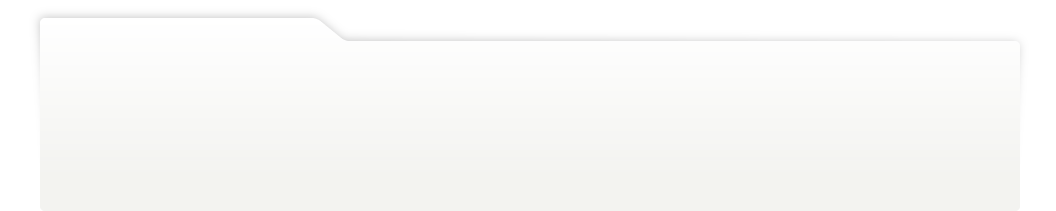
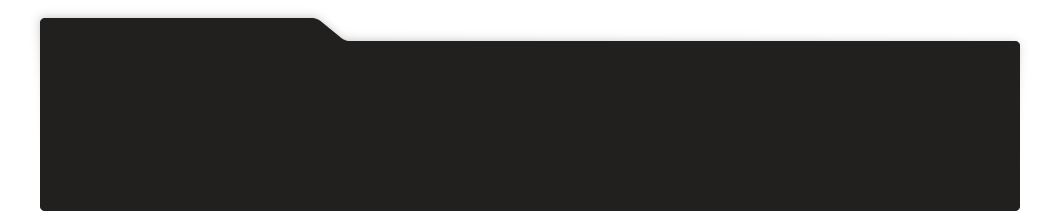
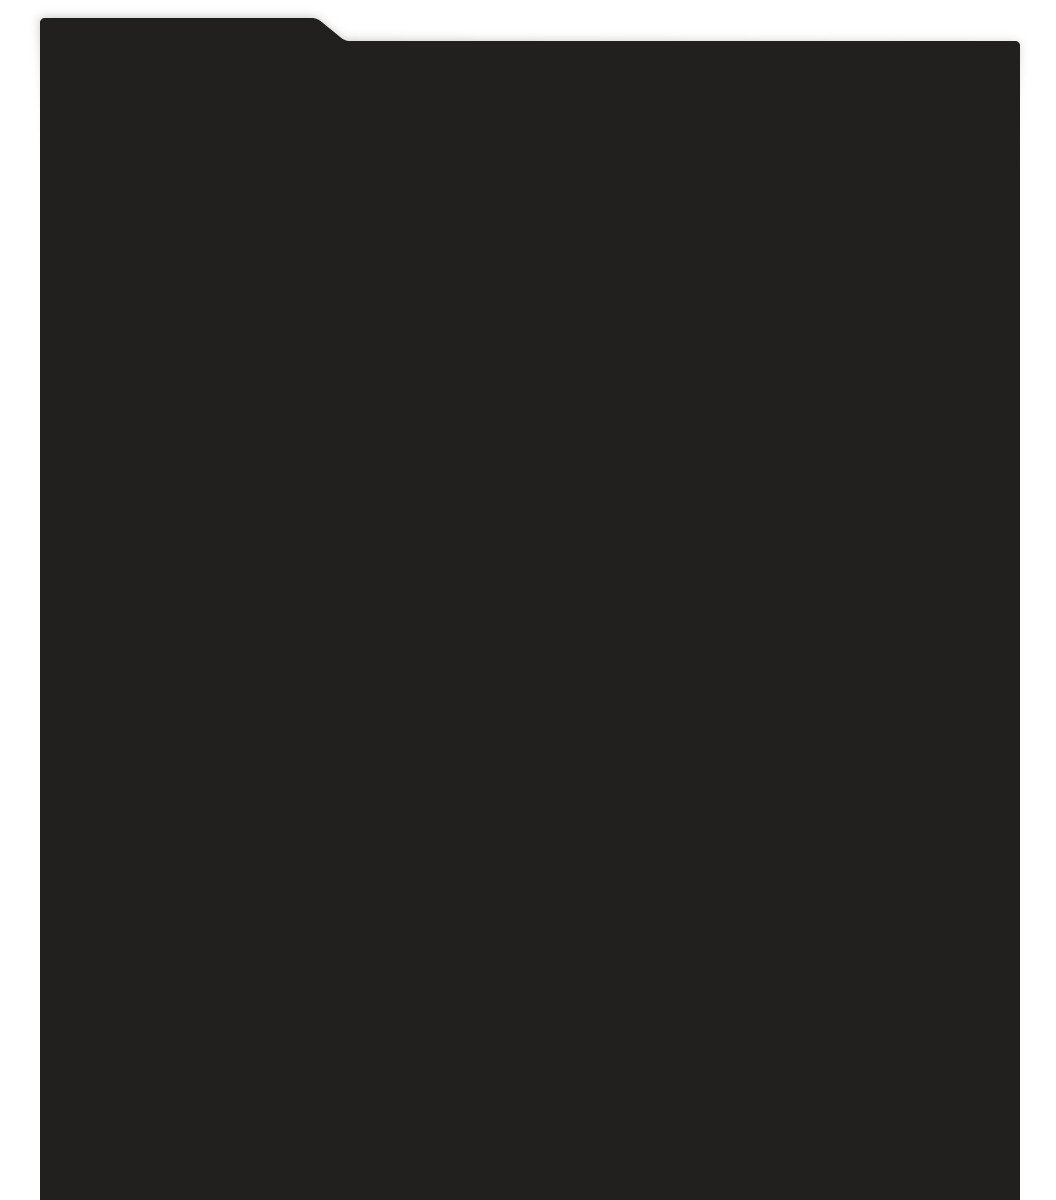
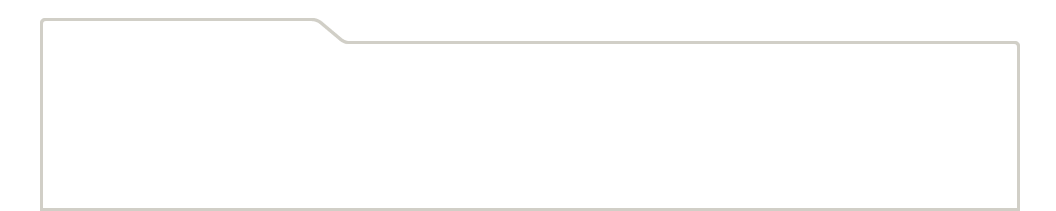
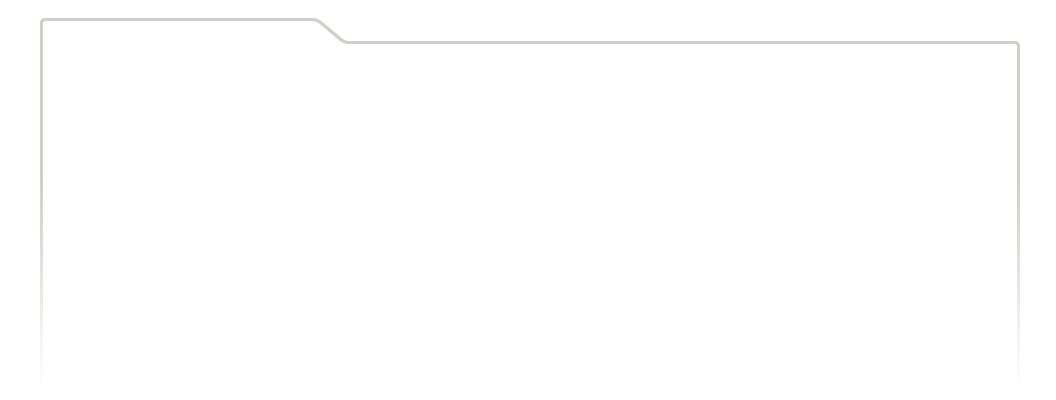
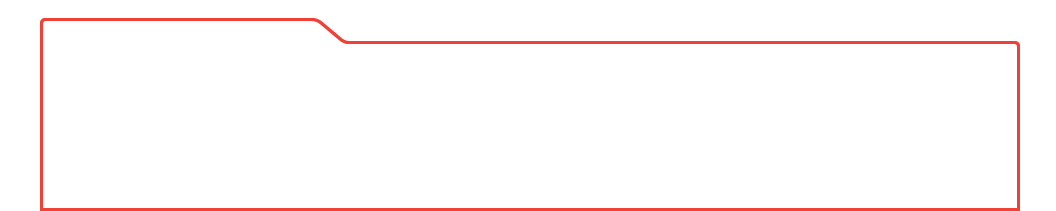
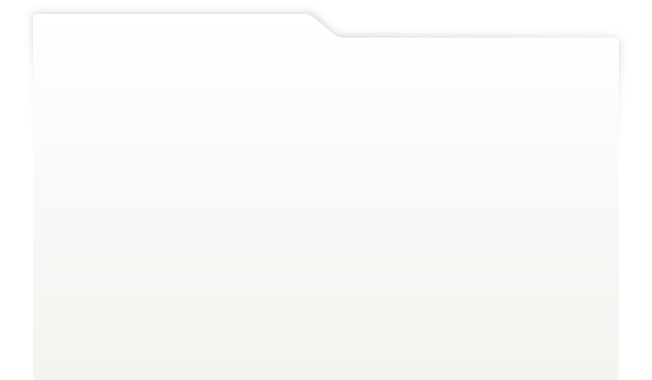
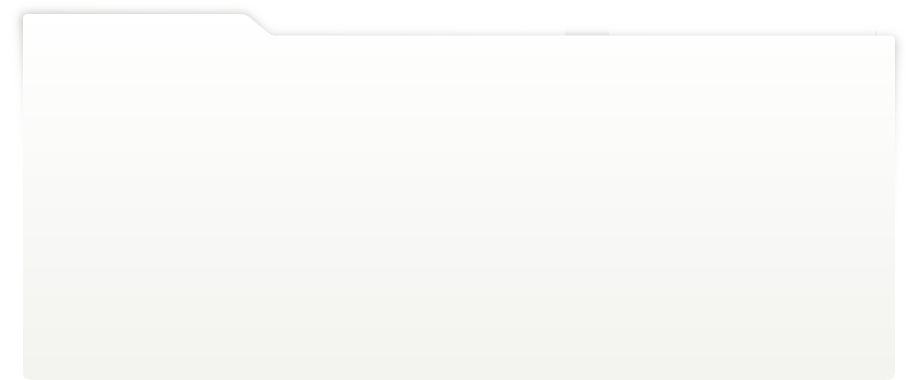
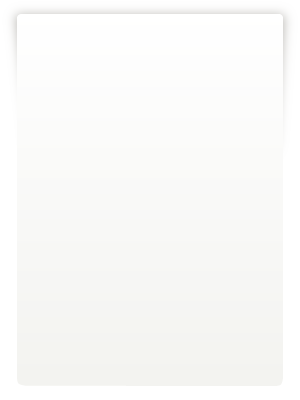
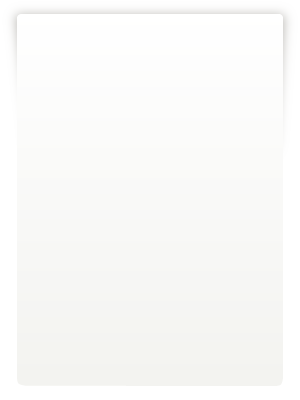
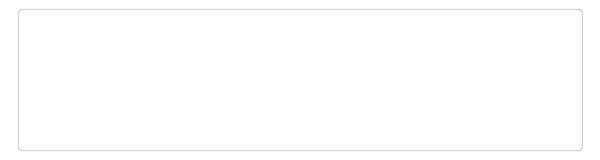
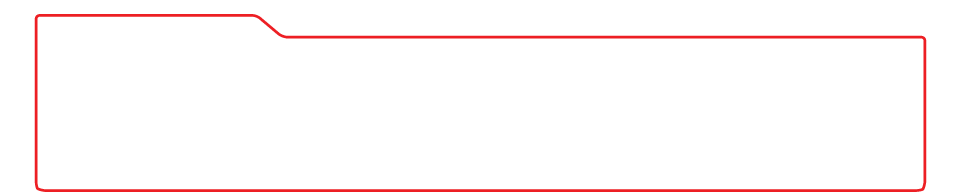
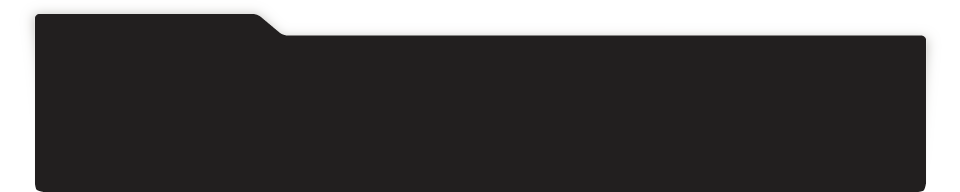
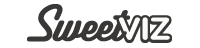
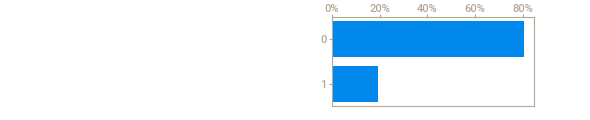
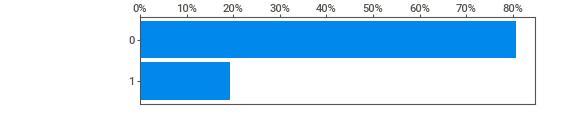
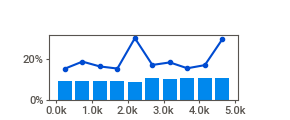
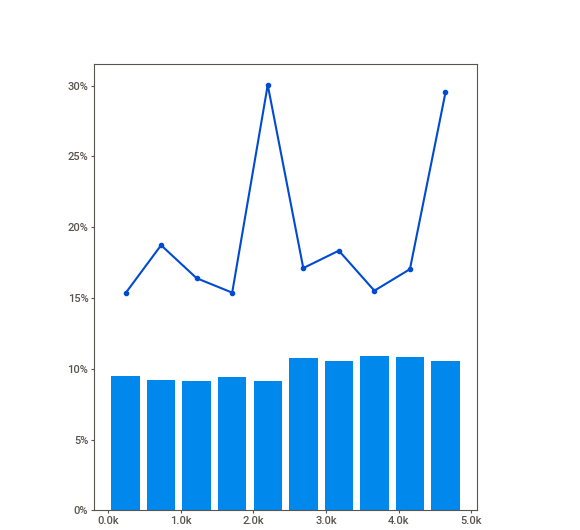
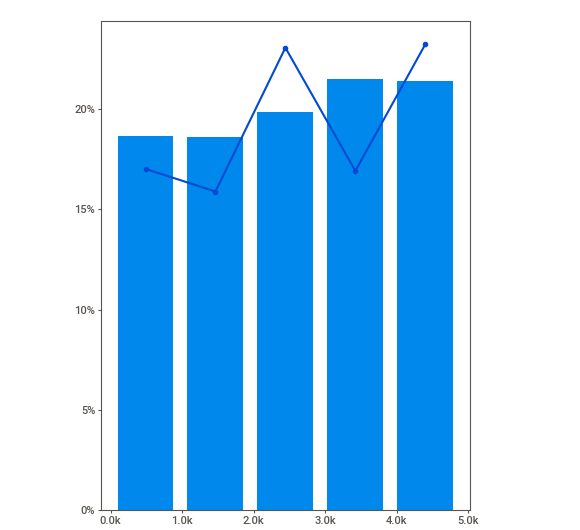
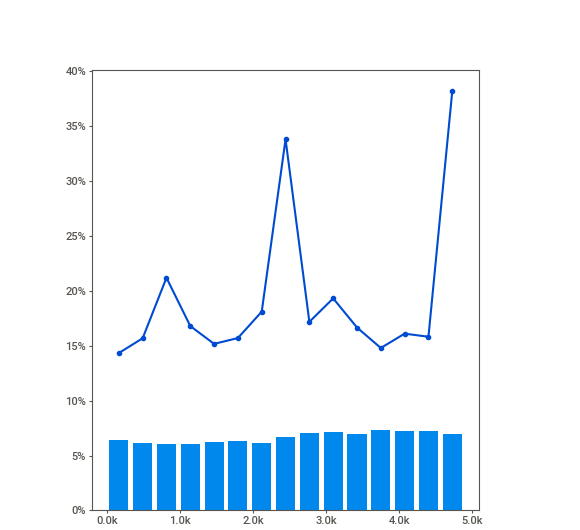
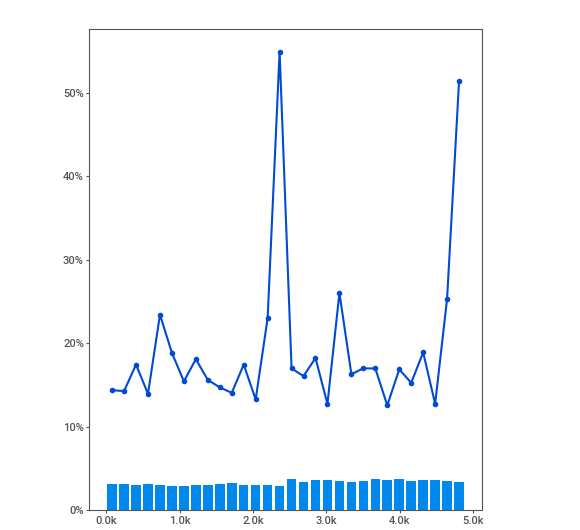
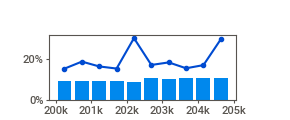
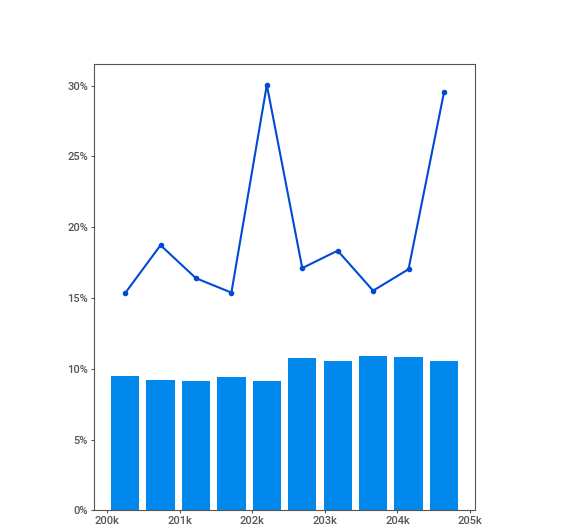
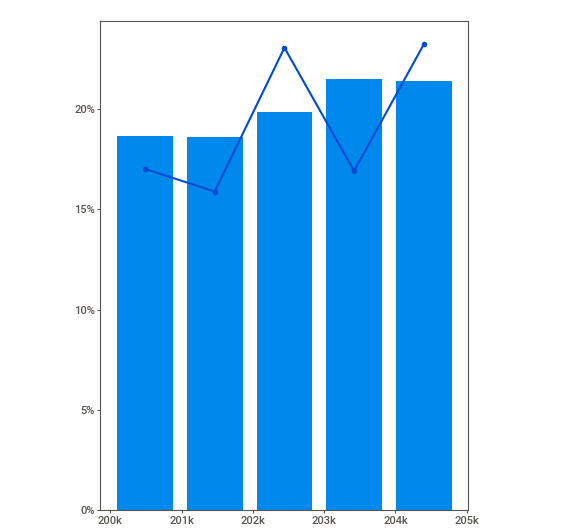
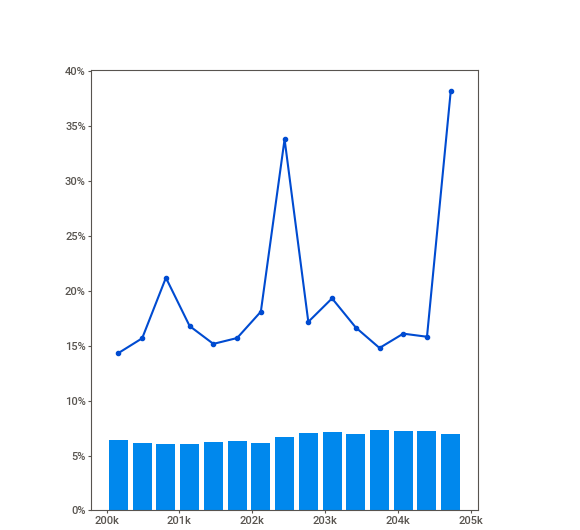
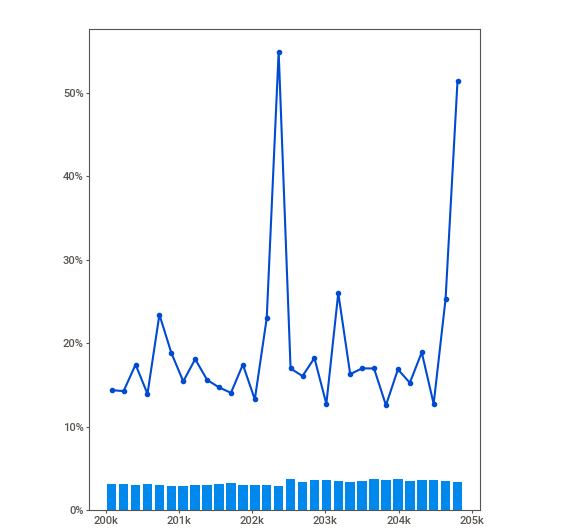
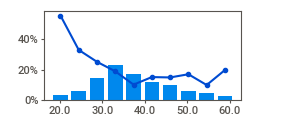
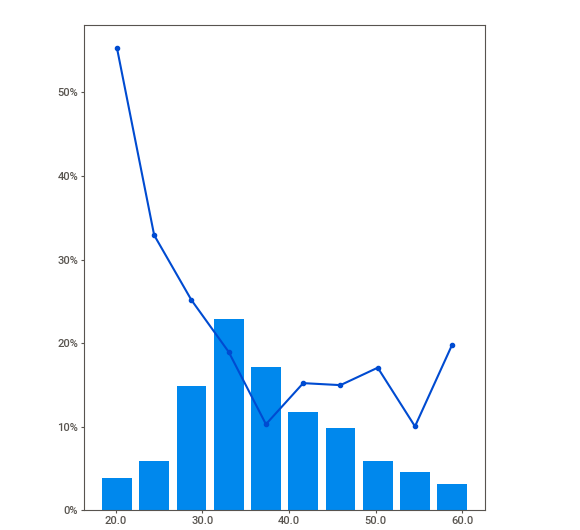
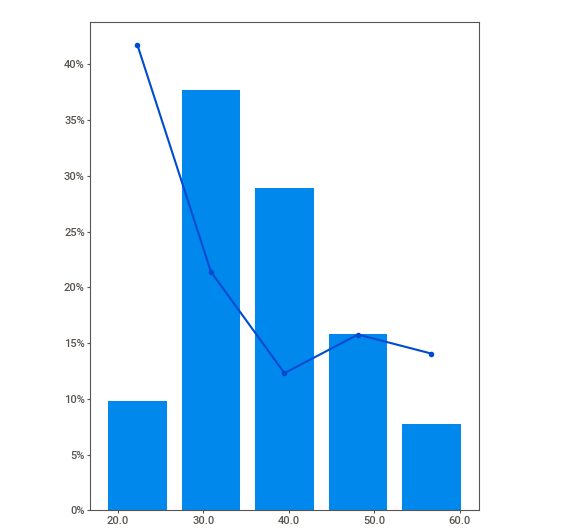
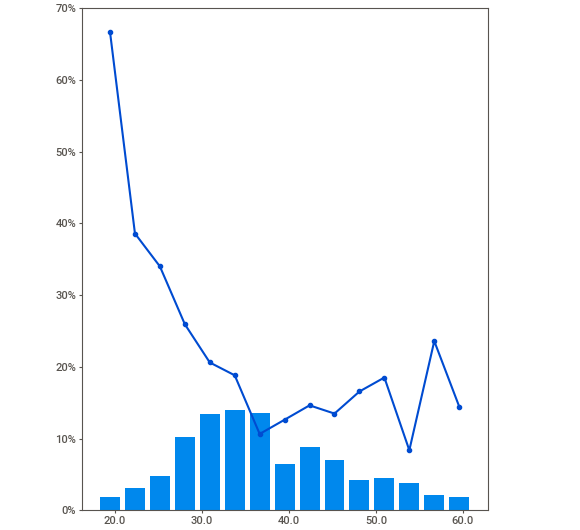
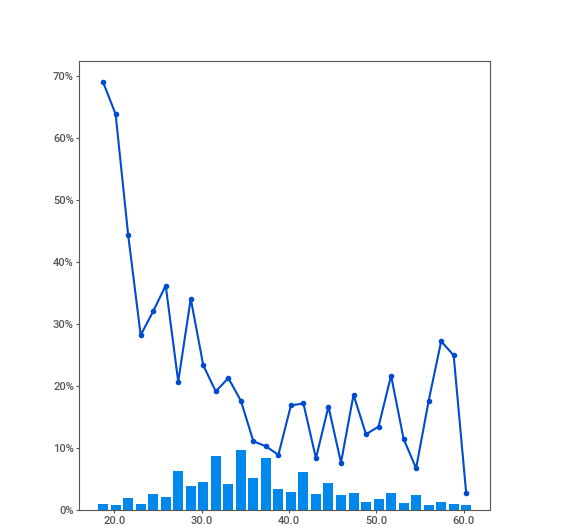
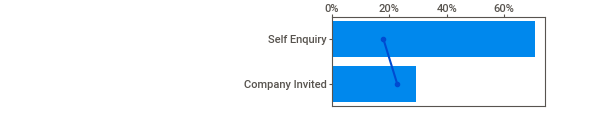
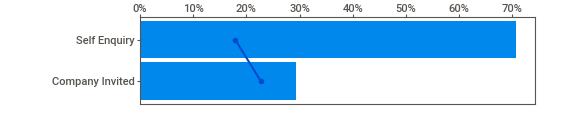
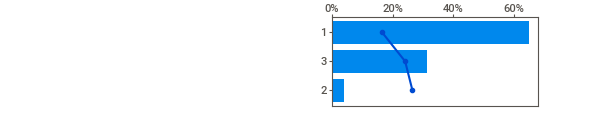
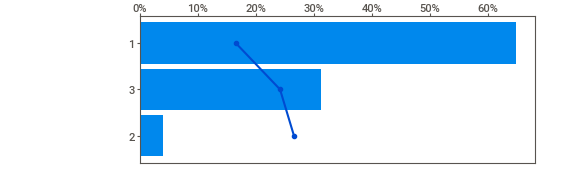
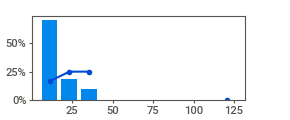
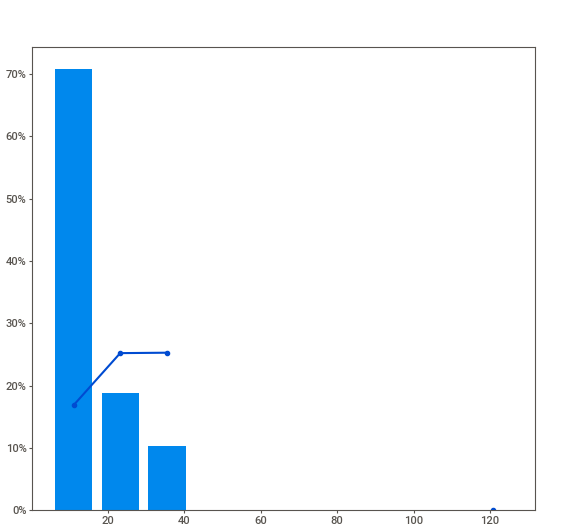
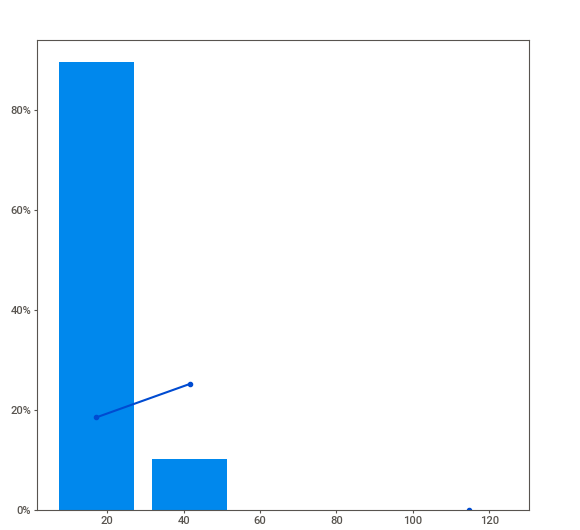
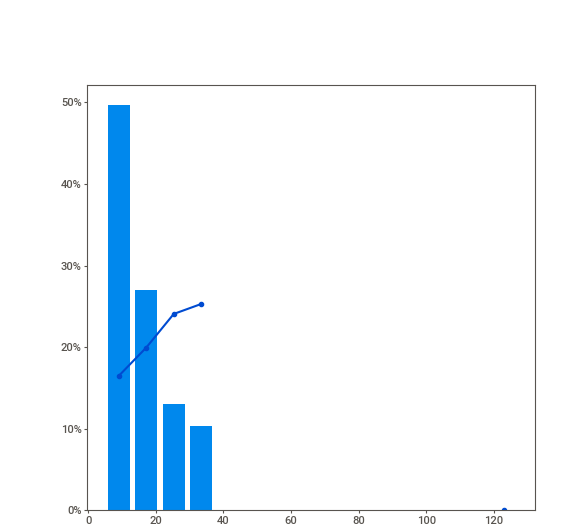
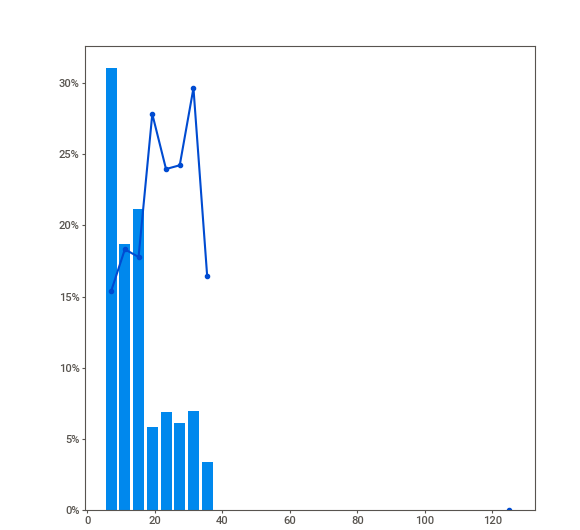
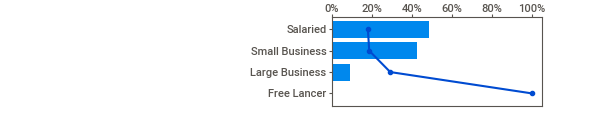
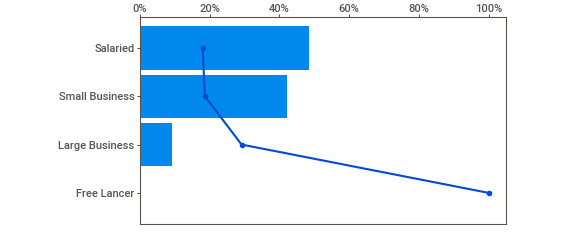
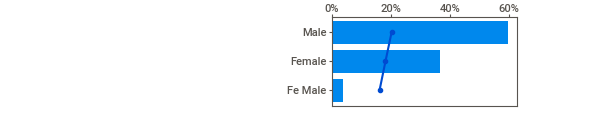
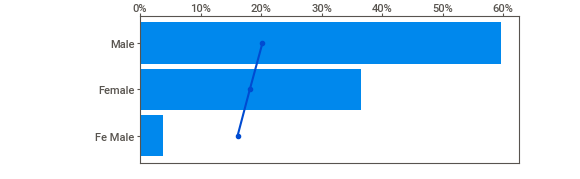
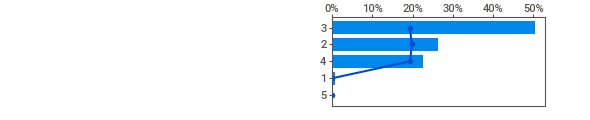
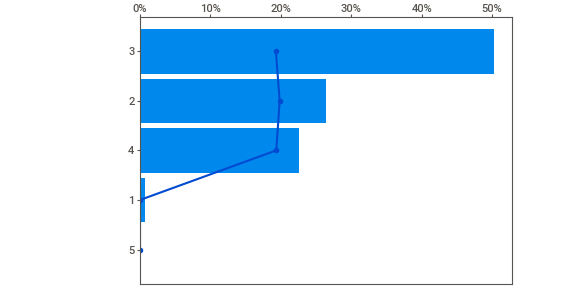
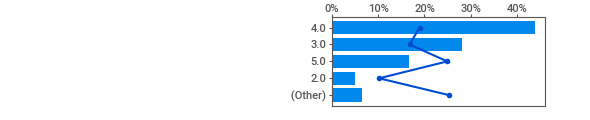
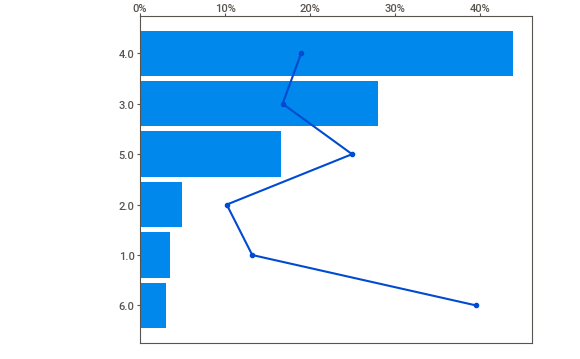
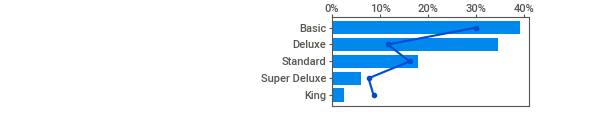
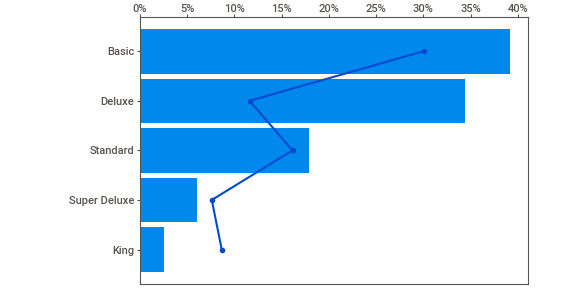
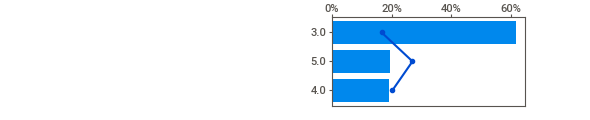
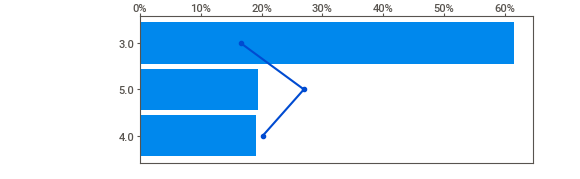
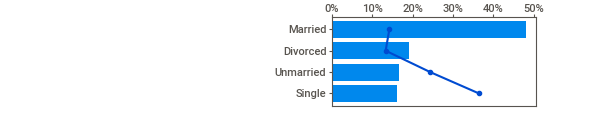
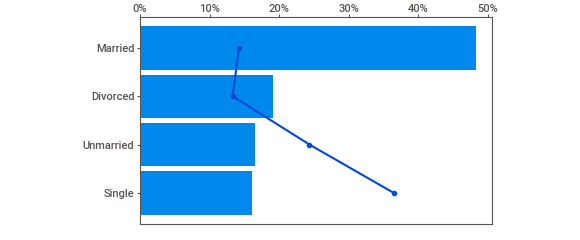
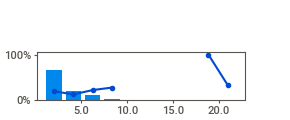
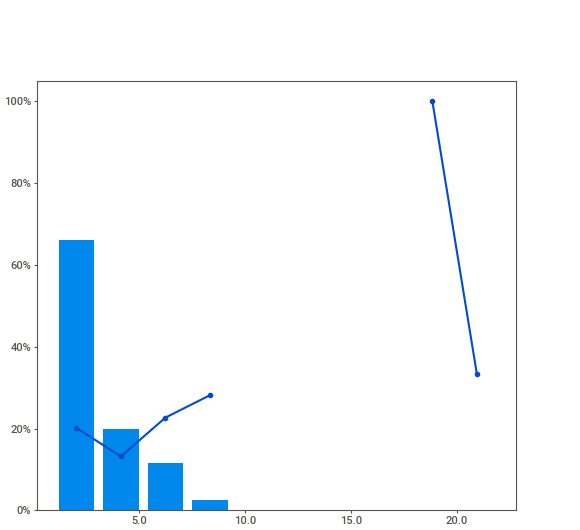
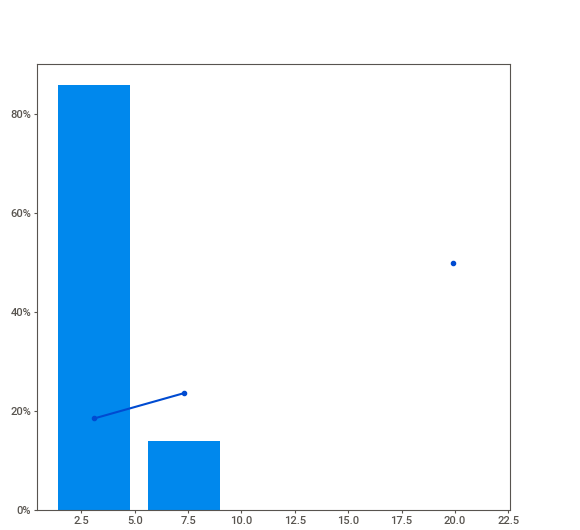
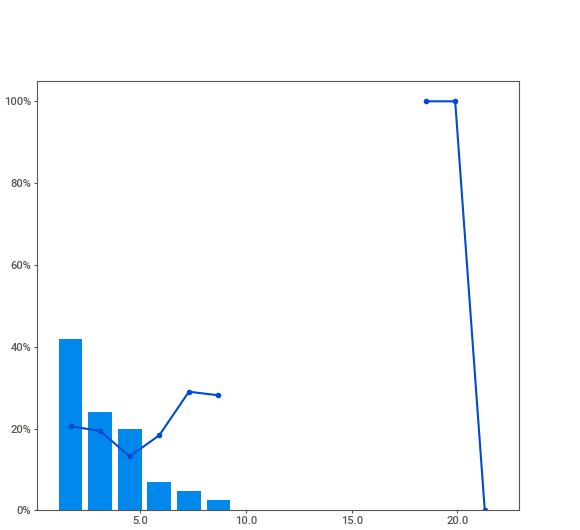
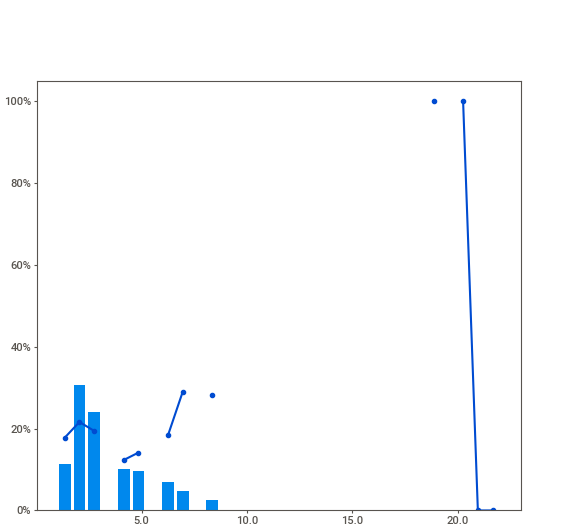
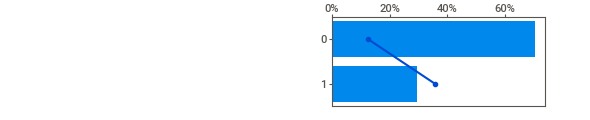
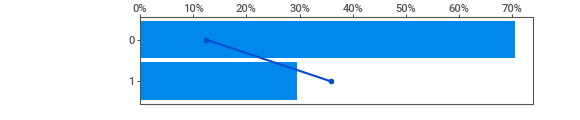
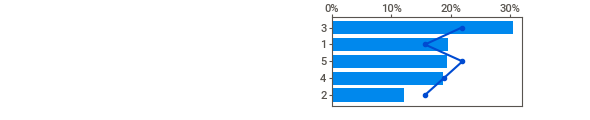
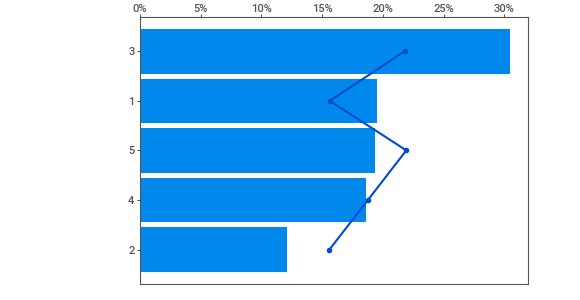
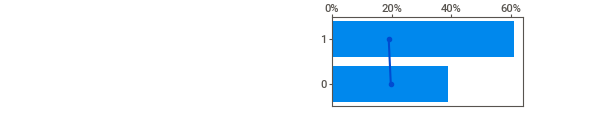
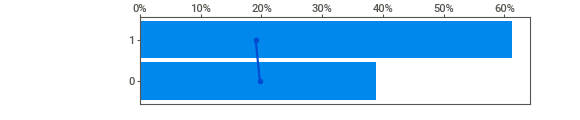
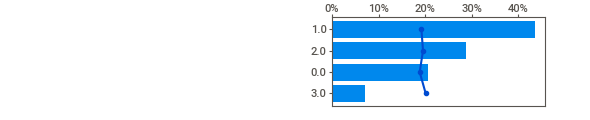
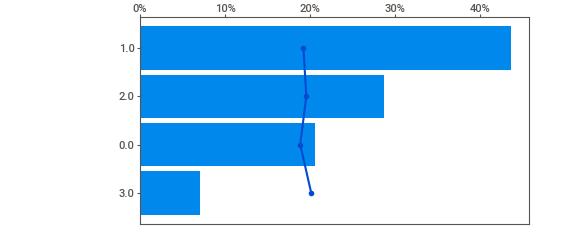
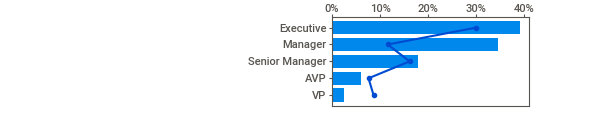
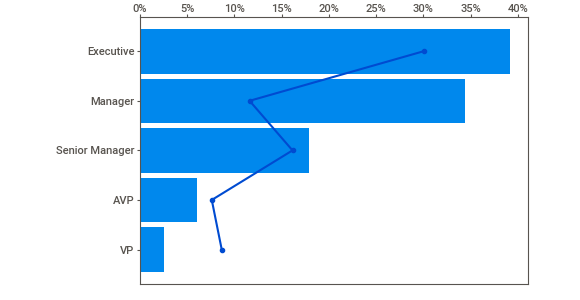
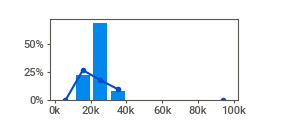
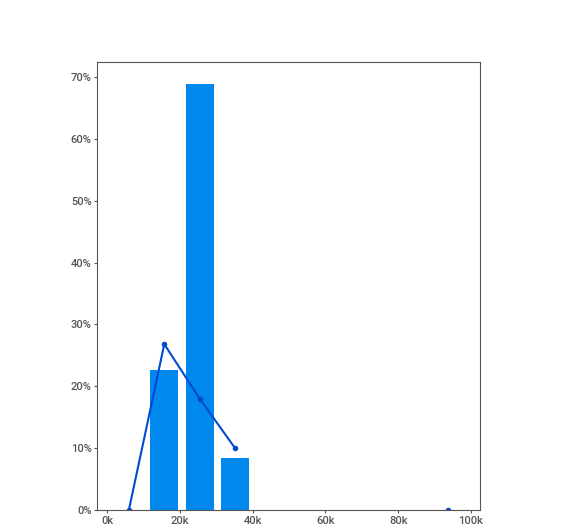
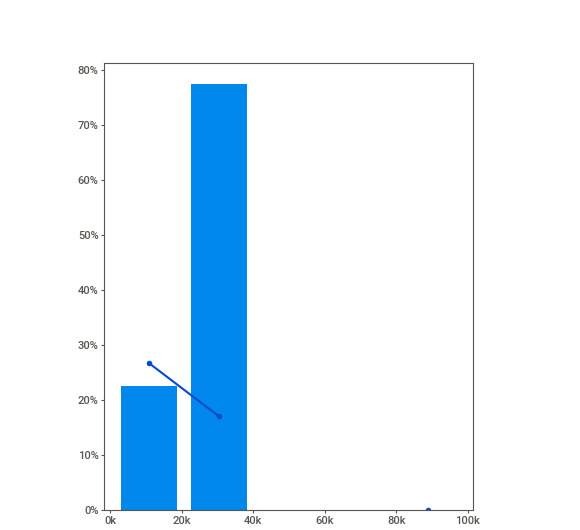
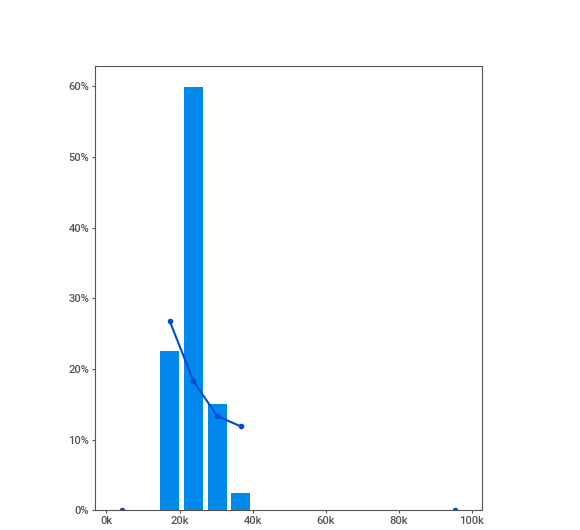
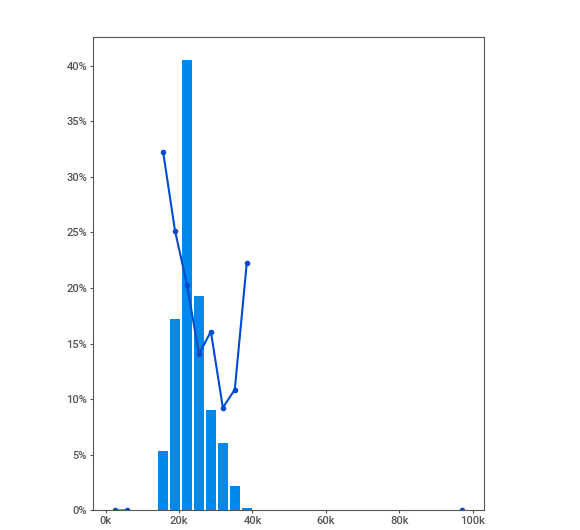
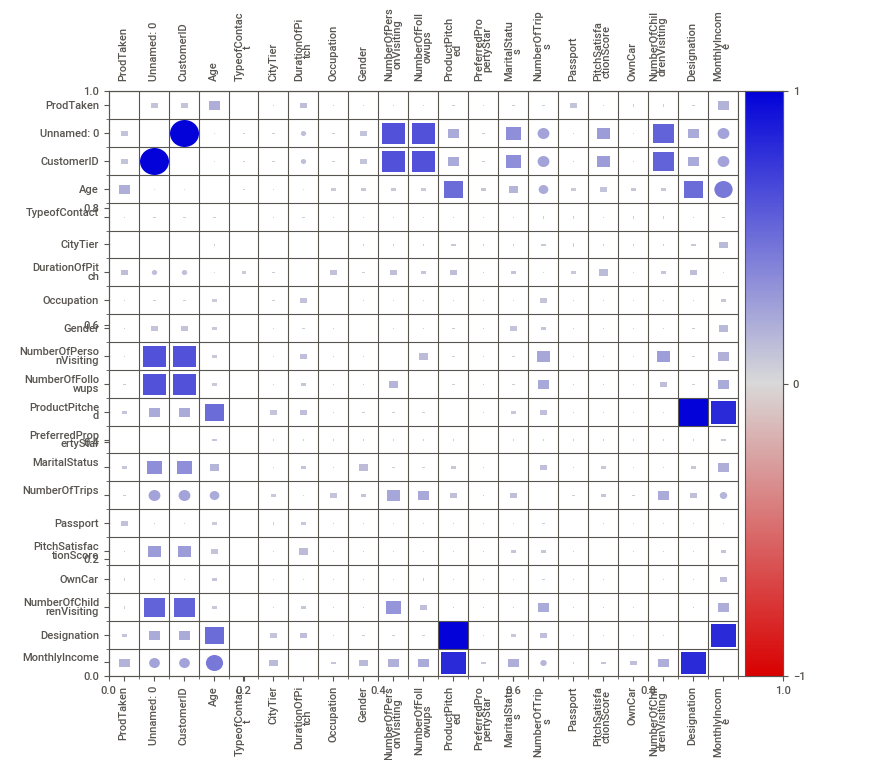
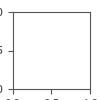

In [10]:
# Explore the dataset using swiftviz: Generate a Sweetviz report for the dataset with the target variable specified

target_col = "ProdTaken"
report = sv.analyze(  df, target_feat=target_col)
report.show_html("kart_Report.html") # Generate HTML report

# Display inline in notebook
report.show_notebook()

**Cleaning Observations and Next Steps**

| Area                          | Observation                                                                                                                   | Next Step                                                                                   |
| ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| **Dataset Size**              | The raw dataset contains **4,128 customer records**.                                                                          | Retain the available records for model development.                                         |
| **Duplicates**                | No exact duplicate rows were identified in the raw dataset.                                                                   | No duplicate removal is required.                                                           |
| **Unnecessary Columns**       | `Unnamed: 0` is an index column, while `CustomerID` is a unique identifier with no predictive value.                          | Remove both columns before modelling.                                                       |
| **Categorical Data**          | Categorical values were trimmed, and the inconsistent `Gender` value **“Fe Male”** will be standardised to **“Female”**.          | Encode categorical variables during model preprocessing.                                    |
| **Missing Values**            | No missing values were identified in the current dataset.                                                                     | No imputation is currently required; retain preprocessing safeguards for future data.       |
| **Target Distribution**       | `ProdTaken` is imbalanced: **80.69% = 0** and **19.31% = 1**.                                                                 | Use a **stratified train-test split** and evaluate models with imbalance-sensitive metrics. |
| **Feature-identical Records** | Some customers may have identical predictor values after removing identifiers. These are not necessarily duplicate customers. | Retain these records to avoid unnecessary data loss.                                        |
| **Model Preparation**         | The cleaned data is ready for model development.                                                                              | Separate `ProdTaken` into **X and y**, then perform the train-test split.                   |
| **Preprocessing**             | Numerical and categorical variables require model-ready transformation.                                                       | Build a `ColumnTransformer`/`Pipeline` for encoding and scaling where required.             |
| **Model Evaluation**          | Accuracy alone may be misleading because of the target imbalance.                                                             | Compare models using **Precision, Recall, F1-score, ROC-AUC, and confusion matrix**.        |
| **Deployment Preparation**    | Preprocessing must remain consistent between training and inference.                                                          | Save the **complete fitted preprocessing + model pipeline** for deployment.                 |


### Define Data Preparation and Exploratory Function

In [11]:
%%writefile src/data_prep.py

import os
import sys
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

import src.hf_utils as hf_utils


load_dotenv()
DATASET_REPO = os.getenv("HF_DATASET_REPO")


def inspect_data(df):
    """
    Inspect and print the structure and quality of the raw dataset.
    """
    print("\n========== RAW DATA INSPECTION ==========")

    print(f"\nDataset shape: {df.shape}")

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nData types and non-null values:")
    df.info()

    print("\nMissing values:")
    display(df.isna().sum())

    print(f"\nDuplicate rows: {df.duplicated().sum()}")


def target_distribution(df, target="ProdTaken"):
    """
    Print the count and percentage distribution of the target variable.
    """
    distribution = pd.DataFrame({
        "Count": df[target].value_counts(),
        "Percentage (%)": (
            df[target]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })

    print("\n========== TARGET DISTRIBUTION ==========")
    display(distribution)


def clean_data(df):
    """
    Clean the dataset by removing unnecessary columns and
    standardising categorical values before model building.
    """
    df = df.copy()

    print("\n========== DATA CLEANING ==========")

    # Step 1: Check and remove true duplicates
    duplicates = df.duplicated().sum()

    print(f"\nStep 1 - Duplicate rows found: {duplicates}")

    if duplicates > 0:
        df = df.drop_duplicates().reset_index(drop=True)
        print(f"Removed {duplicates} duplicate rows.")
    else:
        print("No duplicate rows removed.")

    print(f"Dataset shape: {df.shape}")

    # Step 2: Remove non-predictive columns
    drop_cols = [
        col for col in df.columns
        if col.lower().startswith("unnamed") or col == "CustomerID"
    ]

    print(f"\nStep 2 - Columns removed: {drop_cols}")

    df = df.drop(columns=drop_cols, errors="ignore")

    print(f"Remaining columns ({len(df.columns)}):")
    print(df.columns.tolist())
    print(f"Dataset shape: {df.shape}")

    # Step 3: Standardise categorical values
    cat_cols = df.select_dtypes(
        include=["object", "string"]
    ).columns

    print("\nStep 3 - Categorical columns:")
    print(cat_cols.tolist())

    df[cat_cols] = df[cat_cols].apply(
        lambda col: col.astype("string").str.strip()
    )

    print("Leading/trailing spaces removed.")

    # Step 4: Correct known inconsistent Gender label
    if "Gender" in df.columns:
        print("\nStep 4 - Gender values before correction:")
        print(df["Gender"].value_counts())

        df["Gender"] = df["Gender"].replace(
            "Fe Male", "Female"
        )

        print("\nGender values after correction:")
        print(df["Gender"].value_counts())

    # Step 5: Final missing-value check
    print("\nStep 5 - Missing values after cleaning:")
    display(df.isna().sum())

    print("\n========== CLEANING COMPLETE ==========")
    print(f"Final dataset shape: {df.shape}")
    print(f"Total missing values: {df.isna().sum().sum()}")

    return df


def main(filename, repo_id=None):
    """
    Load raw data from Hugging Face, inspect and clean it,
    then return the cleaned dataframe for model building.
    """
    repo_id = repo_id or DATASET_REPO

    if not repo_id:
        raise ValueError(
            "Set HF_DATASET_REPO in .env or provide repo_id."
        )

   # ========== STEP 1: LOAD DATA ==========

    print(f"Repository: {repo_id}")
    print(f"Filename: {filename}")

    dfs = hf_utils.load_from_hf(
        filenames=filename,
        repo_id=repo_id
    )

    df = dfs[filename]

    print("\nData loaded successfully.")
    print(f"Loaded shape: {df.shape}")

    # ========== STEP 2: INSPECT DATA ==========
    inspect_data(df)

    # ========== STEP 3: CHECK TARGET ==========
    target_distribution(df)

    # ========== STEP 4: CLEAN DATA ==========
    cleaned_df = clean_data(df)

    # ========== FINAL CLEANED DATA ==========

    display("\nFirst 5 rows:")
    display(cleaned_df.head())

    print("\nFinal data types:")
    cleaned_df.info()

    print("\nFinal target distribution:")
    target_distribution(cleaned_df)

    return cleaned_df


if __name__ == "__main__":

    if len(sys.argv) < 2:
        raise ValueError(
            "Usage: python -m src.data_prep tourism.csv"
        )

    filename = sys.argv[1]
    repo_id = sys.argv[2] if len(sys.argv) > 2 else None

    main(filename, repo_id)

Overwriting src/data_prep.py


In [12]:
# Load the raw dataset from Hugging Face and prepare it for model training
import src.data_prep as data_prep # Load the data loading and inspection script

df = data_prep.main(filename=filename,repo_id=DATASET_REPO)


Repository: Omotayof/wellness-tourism-customers
Filename: tourism.csv
  Loaded tourism.csv: (4128, 21)
All requested files loaded successfully.


Data loaded successfully.
Loaded shape: (4128, 21)

========== RAW DATA INSPECTION ==========

Dataset shape: (4128, 21)

First 5 rows:


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128

Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64


Duplicate rows: 0

========== TARGET DISTRIBUTION ==========


,Count,Percentage (%)
ProdTaken,,
0,3331,80.69
1,797,19.31



========== DATA CLEANING ==========

Step 1 - Duplicate rows found: 0
No duplicate rows removed.
Dataset shape: (4128, 21)

Step 2 - Columns removed: ['Unnamed: 0', 'CustomerID']
Remaining columns (19):
['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']
Dataset shape: (4128, 19)

Step 3 - Categorical columns:
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
Leading/trailing spaces removed.

Step 4 - Gender values before correction:
Gender
Male       2463
Female     1510
Fe Male     155
Name: count, dtype: Int64

Gender values after correction:
Gender
Male      2463
Female    1665
Name: count, dtype: Int64

Step 5 - Missing values after cleaning:


ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64


========== CLEANING COMPLETE ==========
Final dataset shape: (4128, 19)
Total missing values: 0


'\nFirst 5 rows:'

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0



Final data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4128 non-null   int64  
 1   Age                       4128 non-null   float64
 2   TypeofContact             4128 non-null   string 
 3   CityTier                  4128 non-null   int64  
 4   DurationOfPitch           4128 non-null   float64
 5   Occupation                4128 non-null   string 
 6   Gender                    4128 non-null   string 
 7   NumberOfPersonVisiting    4128 non-null   int64  
 8   NumberOfFollowups         4128 non-null   float64
 9   ProductPitched            4128 non-null   string 
 10  PreferredPropertyStar     4128 non-null   float64
 11  MaritalStatus             4128 non-null   string 
 12  NumberOfTrips             4128 non-null   float64
 13  Passport                  4128 non-null   in

,Count,Percentage (%)
ProdTaken,,
0,3331,80.69
1,797,19.31


In [13]:
# Demonstrate that the standalone pipeline works
!touch src/__init__.py # create __init__.py to make src a package

! python -m src.data_prep tourism.csv

Repository: Omotayof/wellness-tourism-customers
Filename: tourism.csv
  Loaded tourism.csv: (4128, 21)
All requested files loaded successfully.


Data loaded successfully.
Loaded shape: (4128, 21)

========== RAW DATA INSPECTION ==========

Dataset shape: (4128, 21)

First 5 rows:
   Unnamed: 0  CustomerID  ...  Designation  MonthlyIncome
0           0      200000  ...      Manager        20993.0
1           1      200001  ...      Manager        20130.0
2           2      200002  ...    Executive        17090.0
3           3      200003  ...    Executive        17909.0
4           5      200005  ...    Executive        18068.0

[5 rows x 21 columns]

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 

### Exploratory Feature Analysis

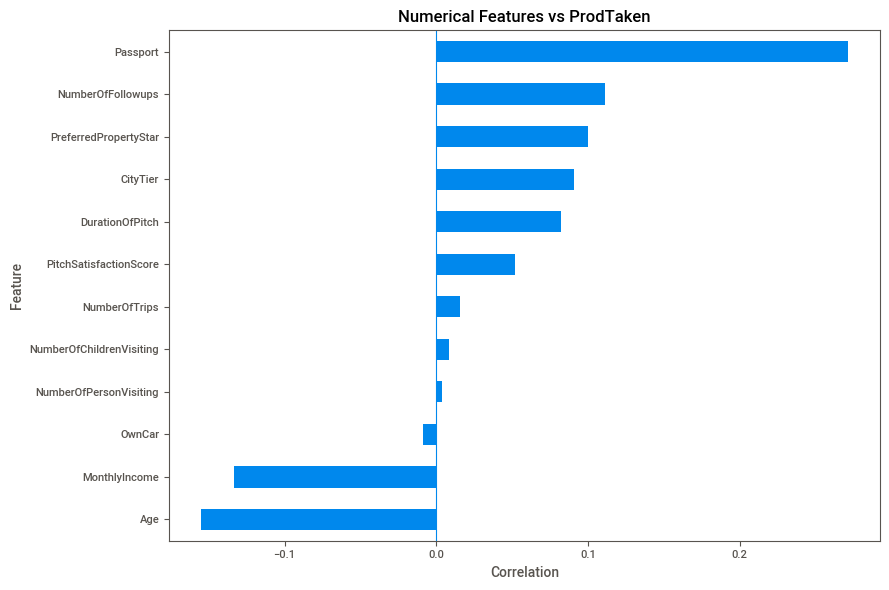

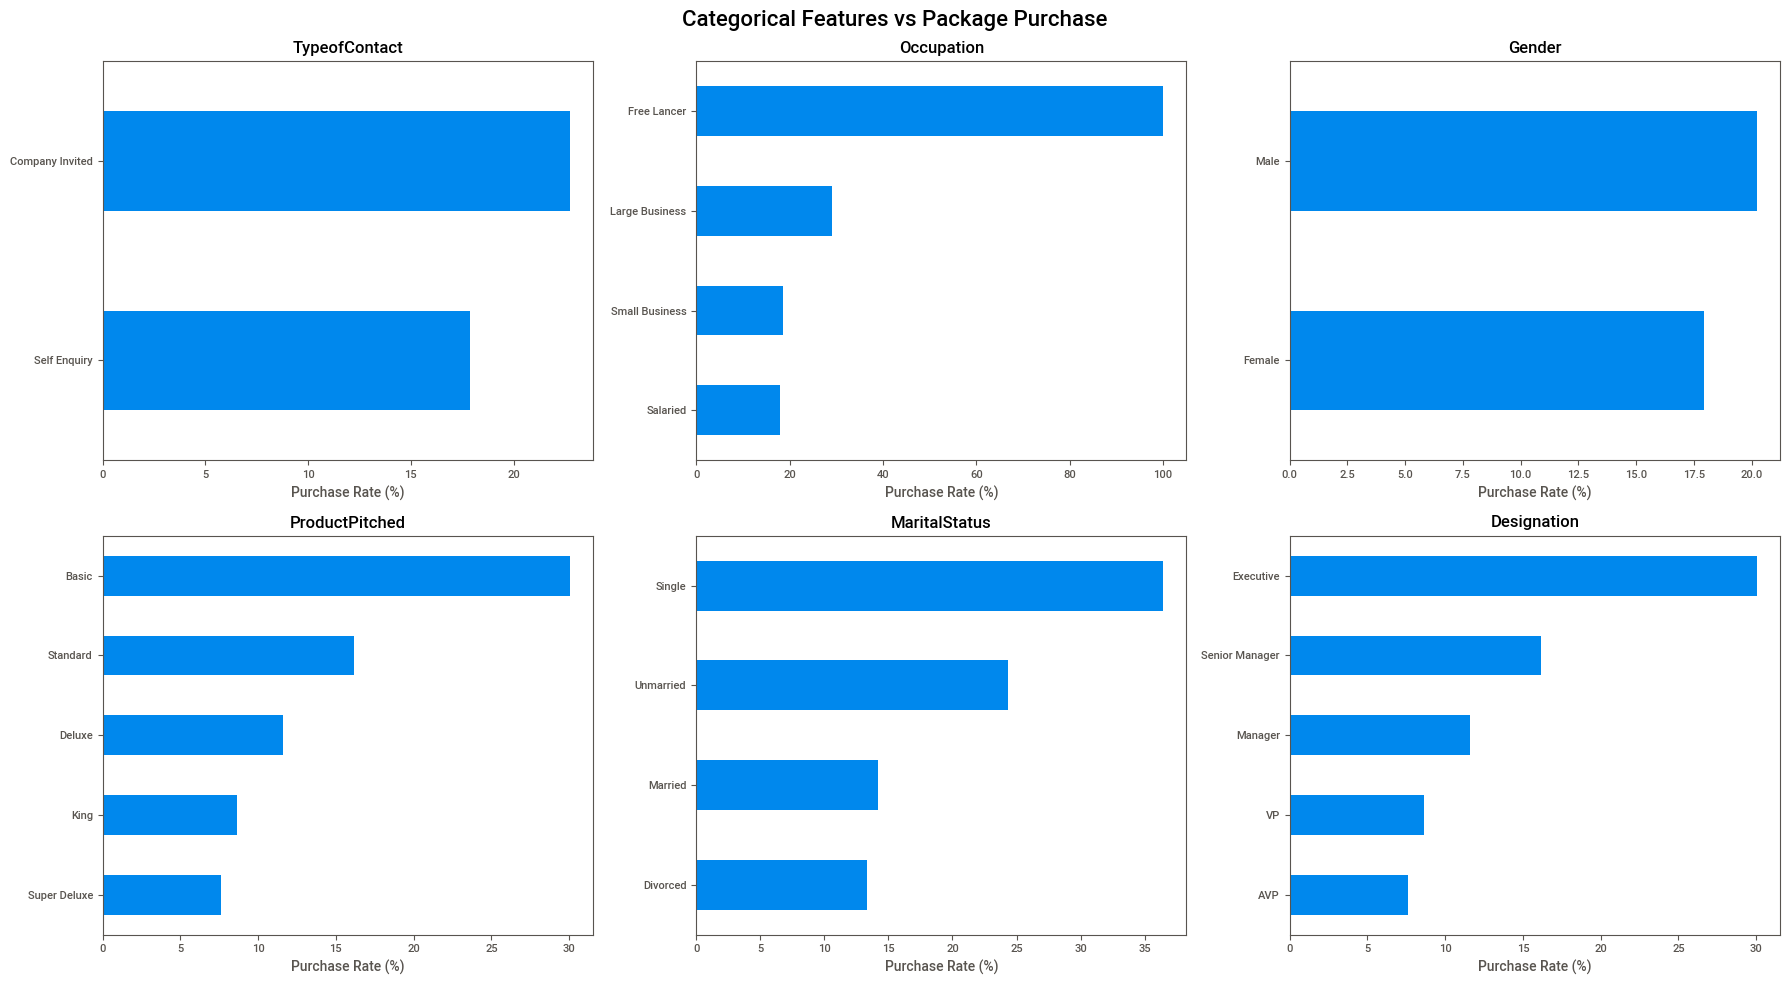

In [14]:
# Identify feature types
numeric_cols = df.select_dtypes(include="number").columns.drop(target_col)
categorical_cols = df.select_dtypes(include=["object", "string"]).columns


# 1. Numerical features vs target
target_corr = (
    df[numeric_cols.tolist() + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values()
)

plt.figure(figsize=(9, 6))
target_corr.plot(kind="barh")

plt.title(f"Numerical Features vs {target_col}")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()


# 2. Categorical features vs target
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):

    (
        df.groupby(col)[target_col]
        .mean()
        .mul(100)
        .sort_values()
        .plot(kind="barh", ax=ax)
    )

    ax.set_title(col)
    ax.set_xlabel("Purchase Rate (%)")
    ax.set_ylabel("")

# Hide unused subplots if any
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.suptitle("Categorical Features vs Package Purchase", fontsize=16)
plt.tight_layout()
plt.show()

| Feature Type    | Key Observations                                                                                                                                                                                                                          | Modelling Decision                                                                                                                                                               |
| --------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Numerical**   | `Passport` has the strongest positive relationship with purchase. `NumberOfFollowups`, `PreferredPropertyStar`, `CityTier` and `DurationOfPitch` also show positive relationships. `Age` and `MonthlyIncome` show strong negative relationships. | Retain **all numerical features**; scale continuous features where appropriate.                                                                                                  |
| **Categorical** | Higher purchase rates are seen for **Free Lancer**, **Single**, **Basic package**, **Executive**, and **Company Invited** customers. Gender shows only a small difference.                                                                | Retain **all categorical features** and apply one-hot encoding.                                                                                                                  |
| **Overall**     | Some features show weak individual relationships, but they may still contribute through interactions or nonlinear patterns.                                                                                                               | **All cleaned features will be used initially for model training.** Feature importance and model performance will be assessed after training before considering feature removal. |


### Data-Splitting & HF Uplaod 

#### Define Model train utility functions

In [15]:
%%writefile src/train_utils.py

import os
import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

from src.hf_utils import upload_to_hf

filepaths= os.path.dirname(os.path.abspath(__file__))
# ---------------------------------------------------------
# 1. SPLIT DATA
# ---------------------------------------------------------
def split_data(
    df,
    target_col="ProdTaken",
    test_size=0.20,
    random_state=42,
    repo_id=None
):
    """
    Split the cleaned dataset into stratified training and test sets,
    save both datasets as CSV files, and upload them to Hugging Face.
    """

    print("\n STEP 2.1: SPLIT DATA ")

    # Separate predictors and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    print(f"\nPredictor features: {X.shape[1]}")
    print(f"Target variable: {target_col}")

    # Stratified train/test split
    print("\nSplitting data using stratification...")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print(f"\nTraining features: {X_train.shape}")
    print(f"Test features:     {X_test.shape}")

    # Check target distribution
    print("\nTraining target distribution (%):")
    print(
        y_train.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nTest target distribution (%):")
    print(
        y_test.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    # Combine features and target
    print("\nCombining features and target for saving...")
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    # Save CSV files
    os.makedirs("data", exist_ok=True)

    train_path = "data/train.csv"
    test_path = "data/test.csv"

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"\nTrain saved: {train_path} {train_df.shape}")
    print(f"Test saved:  {test_path} {test_df.shape}")

    # Upload split datasets to Hugging Face
    if repo_id:
        print(f"\nUploading split datasets to Hugging Face: {repo_id}")

        upload_to_hf(
            local_path=[train_path, test_path],
            repo_id=repo_id
        )

        print("Train and test datasets uploaded successfully.")
    else:
        print("\nNo repo_id provided - upload skipped.")

    return X_train, X_test, y_train, y_test


# ---------------------------------------------------------
# 2. BUILD PREPROCESSING PIPELINE
# ---------------------------------------------------------
def build_preprocessor(X_train):
    """
    Build preprocessing steps from the training features.

    Numerical variables are scaled and categorical
    variables are one-hot encoded.
    """

    print("\n STEP : PREPROCESSING CLEAN DATA ")

    numeric_features = (
        X_train
        .select_dtypes(include="number")
        .columns
        .tolist()
    )

    categorical_features = (
        X_train
        .select_dtypes(include=["object", "string"])
        .columns
        .tolist()
    )

    print("\nNumerical features:")
    print(numeric_features)

    print("\nCategorical features:")
    print(categorical_features)

    print("\nBuilding preprocessing pipeline...")
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )
    print("Preprocessing pipeline created successfully.")

    return preprocessor


# ---------------------------------------------------------
# 3. MODEL DEFINITIONS AND PARAMETER GRIDS
# ---------------------------------------------------------
def get_models_and_params():
    """
    Define candidate classification models and
    hyperparameter search grids.
    """

    models = {
        "decision_tree": DecisionTreeClassifier(random_state=42),

        "bagging": BaggingClassifier(random_state=42),

        "random_forest": RandomForestClassifier(random_state=42),

        "adaboost": AdaBoostClassifier(random_state=42),

        "gradient_boosting": GradientBoostingClassifier(
            random_state=42
        ),

        "xgboost": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        )
    }

    param_grids = {

        "decision_tree": {
            "model__max_depth": [3, 5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        },

        "bagging": {
            "model__n_estimators": [10, 50, 100],
            "model__max_samples": [0.5, 0.7, 1.0],
            "model__max_features": [0.5, 0.7, 1.0]
        },

        "random_forest": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10]
        },

        "adaboost": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 0.5, 1.0]
        },

        "gradient_boosting": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5]
        },

        "xgboost": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.9, 1.0]
        }
    }

    return models, param_grids


# ---------------------------------------------------------
# 4. TRAIN, TUNE AND LOG MODEL
# ---------------------------------------------------------
def train_and_tune(
    model_name,
    model,
    params,
    preprocessor,
    X_train,
    y_train,
    X_test,
    y_test
):
    """
    Train and tune a model using GridSearchCV and
    log its performance in MLflow.
    """

    print(f"\n TRAINING: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    with mlflow.start_run(run_name=model_name):

        # Train only on training data
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        # Evaluate on unseen test data
        predictions = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        # Log results
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_score", f1)

        print(f"\nBest Parameters: {grid.best_params_}")
        display(f"Accuracy: {accuracy:.4f}")
        display(f"F1 Score: {f1:.4f}")

    return best_model, f1, accuracy


# ---------------------------------------------------------
# 5. MODEL PERFORMANCE SUMMARY
# ---------------------------------------------------------
def summarize_models(results):
    """
    Create a summary table of model performance.
    """

    summary = []

    for name, metrics in results.items():

        summary.append({
            "Model": name,
            "Accuracy": round(metrics["accuracy"], 4),
            "F1 Score": round(metrics["f1"], 4)
        })

    df_summary = (
        pd.DataFrame(summary)
        .sort_values(
            "F1 Score",
            ascending=False
        )
    )

    print("\n==========Step 5: MODEL PERFORMANCE ==========")
   # display(df_summary.to_string(index=False))

    return df_summary


# ---------------------------------------------------------
# 6. SELECT BEST MODEL
# ---------------------------------------------------------
def select_best_model(results):
    """
    Select the model with the highest F1 score.
    """

    best_name = max(
        results,
        key=lambda model: results[model]["f1"]
    )

    best_model = results[best_name]["model"]

    print("\n==========Step 6: BEST MODEL ==========")
    print(f"Model: {best_name}")
    print(f"F1 Score: {results[best_name]['f1']:.4f}")

    return best_name, best_model


# ---------------------------------------------------------
# 7. SAVE AND UPLOAD BEST MODEL
# ---------------------------------------------------------
def register_model_hf(
    model,
    model_name,
    model_repo,
    token=None
):
    """
    Save the best model and upload it to Hugging Face Model Hub.
    """

    if token is None:
        token = os.getenv("HF_TOKEN_ML")

    print("\n========== Step 7: REGISTER MODEL ==========")

    os.makedirs("models", exist_ok=True)

    save_path = f"models/{model_name}.joblib"

    # Save model locally
    joblib.dump(model, save_path)

    print(f"Model saved: {save_path}")

    # Upload model to Hugging Face Model Hub
    upload_to_hf(
        local_path=save_path,
        repo_id=model_repo,
        repo_type="model",
        token=token
    )

    print(
        f"Model uploaded to Hugging Face Model Hub: "
        f"{model_repo}/{model_name}.joblib"
    )

    return save_path

Overwriting src/train_utils.py


In [16]:
%%writefile src/train_model.py

import os
import warnings
from dotenv import load_dotenv

from src.data_prep import main as prepare_data
from src.train_utils import (
    split_data,
    build_preprocessor,
    get_models_and_params,
    train_and_tune,
    summarize_models,
    select_best_model,
    register_model_hf
)
from src.hf_utils import (load_from_hf, upload_to_hf)


warnings.filterwarnings("ignore", category=UserWarning)

load_dotenv()

DATASET_REPO = os.getenv("HF_DATASET_REPO")
MODEL_REPO = os.getenv("HF_MODEL_REPO")

TARGET_COL = "ProdTaken"
FILENAME = "tourism.csv"


def main(repo_id=None, model_id=None):
    """
    Run the complete model-building workflow:
    load and clean data, split, preprocess, train,
    evaluate, select and register the best model.
    """

    repo_id = repo_id or DATASET_REPO
    model_id = model_id or MODEL_REPO

    # 1. Load and clean data
    print("\n========== 1. DATA PREPARATION ==========")

    df = prepare_data(
        FILENAME,
        repo_id=repo_id
    )

    # 2. Split data
    print("\n========== 2. TRAIN-TEST SPLIT ==========")

    X_train, X_test, y_train, y_test = split_data(
    df,
    target_col=TARGET_COL,
    repo_id=repo_id
)

    # Load split datasets from Hugging Face
    dfs = load_from_hf(
        ["train.csv", "test.csv"],
        repo_id=DATASET_REPO
    )

    train_df = dfs["train.csv"]
    test_df = dfs["test.csv"]

    # Separate X and y
    X_train = train_df.drop(columns=["ProdTaken"])
    y_train = train_df["ProdTaken"]

    X_test = test_df.drop(columns=["ProdTaken"])
    y_test = test_df["ProdTaken"]
    

    # 3. Build preprocessing pipeline
    print("\n========== 3. PREPROCESSING ==========")

    preprocessor = build_preprocessor(X_train)

    # 4. Load models and parameter grids
    print("\n========== 4. MODEL TRAINING ==========")

    models, param_grids = get_models_and_params()
    results = {}

    # 5. Train and tune all models
    for name, model in models.items():

        best_model, f1, accuracy = train_and_tune(
            model_name=name,
            model=model,
            params=param_grids[name],
            preprocessor=preprocessor,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test
        )

        results[name] = {
            "model": best_model,
            "f1": f1,
            "accuracy": accuracy
        }

    # 6. Compare models
    print("\n========== 5. MODEL COMPARISON ==========")

    summarize_models(results)

    # 7. Select best model
    print("\n========== 6. BEST MODEL ==========")

    best_name, best_model = select_best_model(results)

    # 8. Save and upload best model
    print("\n========== 7. MODEL REGISTRATION ==========")

    register_model_hf(
        model=best_model,
        model_name=best_name,
        model_repo=model_id
    )

    # Save outputs for GitHub Actions

    print("\nSaving model details for GitHub Actions...")

    local_model_path = f"models/{best_name}.joblib"

    model_filename = best_name + ".joblib"

    with open("deployment/model_output.txt", "w") as f:
        f.write(model_filename)

    with open("deployment/model_repo.txt", "w") as f:
        f.write(model_id)

    print(
        f"Saved model name: {model_filename} "
        "→ deployment/model_output.txt"
    )

    print(
        f"Saved model repo: {model_id} "
        "→ deployment/model_repo.txt"
    )

    print("\n========== PIPELINE COMPLETED ==========")

    return best_model, local_model_path, best_name, model_id


if __name__ == "__main__":
    main()

Overwriting src/train_model.py


In [17]:
# Split the data into train and test sets and upload the split files to the local repository and Hugging Face dataset repository. 

import src.train_utils as train_utils  # Load the training utility script
    
X_train, X_test, y_train, y_test = train_utils.split_data( df,target_col=target_col,repo_id=DATASET_REPO)

No files have been modified since last commit. Skipping to prevent empty commit.



 STEP 2.1: SPLIT DATA 

Predictor features: 18
Target variable: ProdTaken

Splitting data using stratification...

Training features: (3302, 18)
Test features:     (826, 18)

Training target distribution (%):
ProdTaken
0    80.68
1    19.32
Name: proportion, dtype: float64

Test target distribution (%):
ProdTaken
0    80.75
1    19.25
Name: proportion, dtype: float64

Combining features and target for saving...

Train saved: data/train.csv (3302, 19)
Test saved:  data/test.csv (826, 19)

Uploading split datasets to Hugging Face: Omotayof/wellness-tourism-customers


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded data/train.csv → train.csv in HF dataset repo: Omotayof/wellness-tourism-customers
Uploaded data/test.csv → test.csv in HF dataset repo: Omotayof/wellness-tourism-customers
Train and test datasets uploaded successfully.


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Model Training and Registration in HF with Experimentation Tracking 

In [18]:
# Load train/test files from Hugging Face

dfs = hf_utils.load_from_hf(
    ["train.csv", "test.csv"],
    repo_id=DATASET_REPO
)

train_df = dfs["train.csv"]
test_df = dfs["test.csv"]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

  Loaded train.csv: (3302, 19)
  Loaded test.csv: (826, 19)
All requested files loaded successfully.

Train shape: (3302, 19)
Test shape: (826, 19)


In [19]:
# Separate features and target

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

In [20]:
# Build preprocessing pipeline

preprocessor = train_utils.build_preprocessor(X_train)


 STEP : PREPROCESSING CLEAN DATA 

Numerical features:
['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']

Categorical features:
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']

Building preprocessing pipeline...
Preprocessing pipeline created successfully.


In [21]:
# Get models, train, tune, and log them in MLflow

models, param_grids = train_utils.get_models_and_params()

print("Models loaded:")
for name in models:
    print("-", name)

Models loaded:
- decision_tree
- bagging
- random_forest
- adaboost
- gradient_boosting
- xgboost


In [22]:
# Train and tune models

results = {}

for name, model in models.items():

    best_model, f1, accuracy = train_utils.train_and_tune(
        model_name=name,
        model=model,
        params=param_grids[name],
        preprocessor=preprocessor,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    results[name] = {
        "model": best_model,
        "f1": f1,
        "accuracy": accuracy
    }


 TRAINING: decision_tree

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


'Accuracy: 0.8983'

'F1 Score: 0.7325'


 TRAINING: bagging

Best Parameters: {'model__max_features': 1.0, 'model__max_samples': 1.0, 'model__n_estimators': 100}


'Accuracy: 0.9262'

'F1 Score: 0.7782'


 TRAINING: random_forest

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}


'Accuracy: 0.9153'

'F1 Score: 0.7328'


 TRAINING: adaboost

Best Parameters: {'model__learning_rate': 1.0, 'model__n_estimators': 200}


'Accuracy: 0.8426'

'F1 Score: 0.4248'


 TRAINING: gradient_boosting

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


'Accuracy: 0.9286'

'F1 Score: 0.7885'


 TRAINING: xgboost

Best Parameters: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.9}


'Accuracy: 0.9407'

'F1 Score: 0.8281'

In [23]:
# Display model results

model_summary = train_utils.summarize_models(results)
display(model_summary)


==========Step 5: MODEL PERFORMANCE ==========


,Model,Accuracy,F1 Score
5,xgboost,0.9407,0.8281
4,gradient_boosting,0.9286,0.7885
1,bagging,0.9262,0.7782
2,random_forest,0.9153,0.7328
0,decision_tree,0.8983,0.7325
3,adaboost,0.8426,0.4248


In [24]:
# Select best model

best_name, best_model = train_utils.select_best_model(results)
print(f"Best model: {best_name}")


==========Step 6: BEST MODEL ==========
Model: xgboost
F1 Score: 0.8281
Best model: xgboost


In [25]:
# Register best model to Hugging Face Model Hub
train_utils.register_model_hf( model=best_model, model_name=best_name, model_repo=MODEL_REPO)


========== Step 7: REGISTER MODEL ==========
Model saved: models/xgboost.joblib


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded models/xgboost.joblib → xgboost.joblib in HF model repo: Omotayof/wellness-tourism-model
Model uploaded to Hugging Face Model Hub: Omotayof/wellness-tourism-model/xgboost.joblib


'models/xgboost.joblib'

In [26]:
# Call the main function to run the complete model-building workflow
import src.train_model as train_model # Load the model training utility script
! python -m src.train_model


========== 1. DATA PREPARATION ==========
Repository: Omotayof/wellness-tourism-customers
Filename: tourism.csv
  Loaded tourism.csv: (4128, 21)
All requested files loaded successfully.


Data loaded successfully.
Loaded shape: (4128, 21)

========== RAW DATA INSPECTION ==========

Dataset shape: (4128, 21)

First 5 rows:
   Unnamed: 0  CustomerID  ...  Designation  MonthlyIncome
0           0      200000  ...      Manager        20993.0
1           1      200001  ...      Manager        20130.0
2           2      200002  ...    Executive        17090.0
3           3      200003  ...    Executive        17909.0
4           5      200005  ...    Executive        18068.0

[5 rows x 21 columns]

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   i

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Push Files to GitHub

```mk

# push all the changes to GitHub repository in terminal mode, you can use the following command to push all the changes to GitHub repository
    !git status
    !git add .
    !git commit -m "Update data preprocessing and model training files"
    !git push   

**Updated Repo Layout**

```mk
        MLOps-Tourism-Package/
        │
        ├── src/
        │   ├── data_prep.py
        │   ├── train_model.py
        │   ├── hf_utils.py
        │   └── train_utils.py
        │
        ├── notebooks/
        │   └── ******.ipynb
        │
        ├── models/
        │   └── bestmodel.joblib
        │
        ├── data/
        │   ├── tourism.csv
        │   ├── train.csv
        │   └── test.csv
        │
        ├── deployment/
        │   ├── model_output.txt
        │   ├── model_repo.txt
        │   └── hf_space/
        │
        ├── .github/workflows/
        │
        ├── requirements.txt
        └── README.md

```

---
# Deployment

For deployment, GitHub Actions CI/CD deployment pipeline will be used alongside the modules train_model.py, streamlit + Hugging Face dataset & model hub 

```mk
    deployment/
    ├── streamlit_app.py          # Streamlit Community Cloud app
    ├── requirements.txt          # Community Cloud requirements
    ├── model_output.txt
    ├── model_repo.txt
    │
    └── hf_space/
        ├── app.py                # FastAPI backend
        ├── streamlit.py          # HF Streamlit frontend
        ├── Dockerfile
        ├── requirements.txt
        └── README.md


## Streamlit Deployment

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Dependency Handling

In [27]:
!pip freeze | grep -E "^(streamlit|pandas|numpy|scikit-learn|xgboost|joblib|huggingface[_-]hub|dill)==" > deployment/requirements.txt
!cat deployment/requirements.txt

dill==0.4.1
huggingface_hub==1.12.0
joblib==1.5.3
numpy==2.4.4
pandas==2.3.3
scikit-learn==1.7.2
streamlit==1.57.0
xgboost==3.2.0


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Dockerfile

In [38]:
%%writefile deployment/Dockerfile

FROM python:3.11-slim

# Set container working directory
WORKDIR /app

# Install dependencies first for Docker caching
COPY requirements.txt .

RUN pip3 install --no-cache-dir -r requirements.txt

# Create non-root user
RUN useradd -m -u 1000 user

# Copy deployment files
COPY --chown=user:user . /app

# Run container as non-root user
USER user

ENV HOME=/home/user \
    PATH=/home/user/.local/bin:$PATH

# Hugging Face Docker Spaces use port 7860
EXPOSE 7860

CMD [
    "streamlit",
    "run",
    "streamlit_app.py",
    "--server.address=0.0.0.0",
    "--server.port=7860",
    "--server.enableXsrfProtection=false"
]

Overwriting deployment/Dockerfile


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Streamlit App

In [29]:
%%writefile deployment/streamlit_app.py

import os
import joblib
import pandas as pd
import streamlit as st

from huggingface_hub import hf_hub_download

# =========================================================
# PAGE CONFIGURATION
# =========================================================
st.set_page_config(
    page_title="Tourism Wellness Package Prediction",
    page_icon="🌍",
    layout="wide"
)

# =========================================================
# MODEL CONFIGURATION
# =========================================================
with open("deployment/model_output.txt", "r") as f:
    MODEL_FILENAME = f.read().strip()

with open("deployment/model_repo.txt", "r") as f:
    MODEL_REPO = f.read().strip()


# Streamlit Cloud secret first, then local environment
try:
    HF_TOKEN = st.secrets["HF_TOKEN_ML"]
except Exception:
    HF_TOKEN = os.getenv("HF_TOKEN_ML")


CLASSIFICATION_THRESHOLD = 0.45

# =========================================================
# LOAD MODEL
# =========================================================
@st.cache_resource
def load_model():
    """
    Download and load the trained ML pipeline from Hugging Face Model Hub.
    """

    model_path = hf_hub_download(  repo_id=MODEL_REPO,  filename=MODEL_FILENAME,    repo_type="model",   token=HF_TOKEN )

    return joblib.load(model_path)

model = load_model()

# =========================================================
# MODEL INFORMATION
# =========================================================
# Identify final model automatically
if hasattr(model, "named_steps"):

    pipeline_steps = list(model.named_steps.keys())
    final_step_name = pipeline_steps[-1]
    final_model = model.named_steps[final_step_name]

    MODEL_TYPE = type(final_model).__name__

else:

    pipeline_steps = ["Model"]
    final_model = model

    MODEL_TYPE = type(model).__name__


INPUT_FEATURES = [
    "Age",
    "TypeofContact",
    "CityTier",
    "DurationOfPitch",
    "Occupation",
    "Gender",
    "NumberOfPersonVisiting",
    "NumberOfFollowups",
    "ProductPitched",
    "PreferredPropertyStar",
    "MaritalStatus",
    "NumberOfTrips",
    "Passport",
    "PitchSatisfactionScore",
    "OwnCar",
    "NumberOfChildrenVisiting",
    "Designation",
    "MonthlyIncome"
]

# =========================================================
# SIDEBAR
# =========================================================
st.sidebar.title("🌍 Tourism Wellness Package")
page = st.sidebar.radio("Navigation", [ "Prediction", "Model Information"   ])
st.sidebar.divider()
st.sidebar.caption("MLOps Tourism Package Prediction")

# =========================================================
# PREDICTION PAGE
# =========================================================
if page == "Prediction":

    st.title("🌍 Tourism Wellness Package Prediction")
    st.write( "Enter the customer's information below to predict "  "their likelihood of purchasing the tourism package." )
    st.divider()

    # -----------------------------------------------------
    # INPUT FORM
    # -----------------------------------------------------

    with st.form("prediction_form"):

        # =================================================
        # CUSTOMER PROFILE
        # =================================================
        st.subheader("Customer Profile")

        col1, col2 = st.columns(2)

        with col1:
            Age = st.number_input(  "Age",min_value=18,  max_value=100, value=30)
            Gender = st.selectbox("Gender", ["Male", "Female"])
            MaritalStatus = st.selectbox( "Marital Status", [ "Married","Single","Divorced",  "Unmarried"  ] )

        with col2:
            Occupation = st.selectbox("Occupation",["Salaried", "Small Business", "Large Business", "Free Lancer"] )
            Designation = st.selectbox( "Designation",["Executive","Manager", "Senior Manager","AVP","VP","Other"])
            MonthlyIncome = st.number_input( "Monthly Income", min_value=0.0,value=30000.0,step=1000.0 )

        st.divider()

        # =================================================
        # TRAVEL & HOUSEHOLD
        # =================================================
        st.subheader("Travel & Household Information")

        col1, col2 = st.columns(2)

        with col1:
            CityTier = st.selectbox("City Tier",[1, 2, 3])
            NumberOfTrips = st.number_input("Number of Trips",min_value=0,value=3)
            Passport = st.selectbox("Has Passport?",[ "No","Yes"])

        with col2:
            NumberOfPersonVisiting = st.number_input("Number of Persons Visiting",  min_value=1, value=2)
            NumberOfChildrenVisiting = st.number_input( "Number of Children Visiting", min_value=0, value=1)
            OwnCar = st.selectbox("Owns a Car?",[ "No", "Yes"] )

        st.divider()

        # =================================================
        # SALES & PACKAGE INFORMATION
        # =================================================
        st.subheader("Sales & Package Information")

        col1, col2 = st.columns(2)

        with col1:
            TypeofContact = st.selectbox("Type of Contact", ["Self Enquiry","Company Invited"])
            ProductPitched = st.selectbox( "Product Pitched",  ["Basic", "Standard","Deluxe","Super Deluxe","King"])
            DurationOfPitch = st.number_input( "Duration of Pitch (Minutes)", min_value=0, value=15 )

        with col2:
            NumberOfFollowups = st.number_input("Number of Follow-ups",min_value=0,value=3 )
            PitchSatisfactionScore = st.selectbox( "Pitch Satisfaction Score",[1, 2, 3, 4, 5])
            PreferredPropertyStar = st.selectbox("Preferred Property Star",[1, 2, 3, 4, 5] )

        st.write("")

        submitted = st.form_submit_button( "Predict Purchase Likelihood",use_container_width=True   )

    # =====================================================
    # PREDICTION
    # =====================================================
    if submitted:

        input_data = pd.DataFrame([{
            "Age": Age,
            "TypeofContact": TypeofContact,
            "CityTier": CityTier,
            "DurationOfPitch": DurationOfPitch,
            "Occupation": Occupation,
            "Gender": Gender,
            "NumberOfPersonVisiting": NumberOfPersonVisiting,
            "NumberOfFollowups": NumberOfFollowups,
            "ProductPitched": ProductPitched,
            "PreferredPropertyStar": PreferredPropertyStar,
            "MaritalStatus": MaritalStatus,
            "NumberOfTrips": NumberOfTrips,
            "Passport": 1 if Passport == "Yes" else 0,
            "PitchSatisfactionScore": PitchSatisfactionScore,
            "OwnCar": 1 if OwnCar == "Yes" else 0,
            "NumberOfChildrenVisiting": NumberOfChildrenVisiting,
            "Designation": Designation,
            "MonthlyIncome": MonthlyIncome

        }])

        probability = model.predict_proba( input_data )[0, 1]
        prediction = int(probability >= CLASSIFICATION_THRESHOLD)

        # -------------------------------------------------
        # RESULT
        # -------------------------------------------------
        st.divider()
        st.subheader("Prediction Result")
        result_col1, result_col2 = st.columns(2)

        with result_col1:

            if prediction == 1:
                st.success("Likely to Purchase" )
                st.write( "The customer is predicted to be a potential buyer of the tourism package." )
            else:
                st.warning("Unlikely to Purchase"  )
                st.write("The customer is currently predicted to have a lower likelihood of purchasing.")

        with result_col2:
            st.metric("Purchase Probability",f"{probability:.2%}" )
            st.progress( float(probability))

        st.caption(f"Classification threshold: "  f"{CLASSIFICATION_THRESHOLD:.0%}" )

# =========================================================
# MODEL INFORMATION PAGE
# =========================================================
elif page == "Model Information":

    st.title("Model Information")
    st.write("Information about the machine-learning model used by the prediction application.")
    st.divider()

    # -----------------------------------------------------
    # MODEL SUMMARY
    # -----------------------------------------------------
    st.subheader("Model Summary")
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric( "Input Features", len(INPUT_FEATURES) )

    with col2:
        st.metric( "Classification Threshold",f"{CLASSIFICATION_THRESHOLD:.0%}")

    with col3:
        st.metric( "Model Type", MODEL_TYPE )

    st.divider()

    # -----------------------------------------------------
    # DEPLOYED MODEL
    # -----------------------------------------------------
    st.subheader("Deployed Model")
    col1, col2 = st.columns(2)

    with col1:
        st.write("**Model File**")
        st.code( MODEL_FILENAME,language=None)

    with col2:
        st.write("**Hugging Face Model Repository**")
        st.code(MODEL_REPO,language=None)

    # -----------------------------------------------------
    # PIPELINE
    # -----------------------------------------------------
        st.subheader("⚙️ Machine Learning Pipeline")
        st.write("The deployed object contains both preprocessing and the trained classifier, ensuring the same transformations are applied during training and inference." )

        if hasattr(model, "named_steps"):

            pipeline_df = pd.DataFrame({
                "Step": range(
                    1,
                    len(model.named_steps) + 1
                ),

                "Pipeline Component": [
                    name
                    for name in model.named_steps.keys()
                ],

                "Type": [
                    type(component).__name__
                    for component in model.named_steps.values()
                ]

            })

            st.dataframe(  pipeline_df,use_container_width=True,    hide_index=True)

    # -----------------------------------------------------
    # FEATURES
    # -----------------------------------------------------
    st.subheader("Model Input Features")
    st.write("The application collects **18 original customer features**. Categorical variables are subsequently transformed by the preprocessing pipeline before prediction." )

    feature_col1, feature_col2 = st.columns(2)
    midpoint = len(INPUT_FEATURES) // 2

    with feature_col1:
        for feature in INPUT_FEATURES[:midpoint]:
            st.write(f"• {feature}"  )

    with feature_col2:
        for feature in INPUT_FEATURES[midpoint:]:
            st.write(f"• {feature}" )

    st.divider()

    # -----------------------------------------------------
    # MODEL WORKFLOW
    # -----------------------------------------------------
    st.subheader("MLOps Workflow")
    st.markdown(
        """
        **1. Dataset Registration**  
        Raw tourism data is stored in the Hugging Face Dataset Hub.

        **2. Data Preparation**  
        Data cleaning, preprocessing and stratified train/test splitting are performed automatically.

        **3. Model Training & Evaluation**  
        Multiple classification models are tuned and evaluated using cross-validation.

        **4. Model Selection**  
        The best-performing model is selected using F1 score.

        **5. Model Registry**  
        The final trained pipeline is stored in the Hugging Face Model Hub.

        **6. Deployment**  
        Streamlit Community Cloud downloads the registered model and provides real-time predictions.
        """
    )

    # -----------------------------------------------------
    # PREDICTION LOGIC
    # -----------------------------------------------------
    with st.expander("How is the prediction calculated?"):
        st.write(
            """
            The model generates the probability that a customer will purchase the tourism package.

            A probability greater than or equal to the classification threshold is classified as **Likely to Purchase**.
            """
        )

        st.code(
            """
            probability = model.predict_proba(customer_data)[0, 1]
            prediction = int(probability >= 0.45 )
            """,
            language="python"
        )

Overwriting deployment/streamlit_app.py


## Hugginface Space Deployment

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

In [30]:
%%writefile deployment/hf_space/app.py

import os
from pathlib import Path

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from huggingface_hub import hf_hub_download
from pydantic import BaseModel


# ---------------------------------------------------------
# APPLICATION
# ---------------------------------------------------------
app = FastAPI(
    title="Tourism Wellness Prediction API",
    description="Prediction API for the Wellness Tourism Package model.",
    version="1.0.0"
)

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
BASE_DIR = Path(__file__).resolve().parent

MODEL_REPO_FILE = BASE_DIR / "model_repo.txt"
MODEL_OUTPUT_FILE = BASE_DIR / "model_output.txt"

# ---------------------------------------------------------
# MODEL CONFIGURATION
# ---------------------------------------------------------
MODEL_REPO = (
    MODEL_REPO_FILE.read_text().strip()
    if MODEL_REPO_FILE.exists()
    else os.getenv("HF_MODEL_REPO")
)

MODEL_FILENAME = (
    MODEL_OUTPUT_FILE.read_text().strip()
    if MODEL_OUTPUT_FILE.exists()
    else os.getenv("MODEL_FILENAME")
)

HF_TOKEN = os.getenv("HF_TOKEN_ML")

if not MODEL_REPO:
    raise RuntimeError("Model repository is not configured." )

if not MODEL_FILENAME:
    raise RuntimeError("Model filename is not configured." )

# ---------------------------------------------------------
# INPUT SCHEMA
# ---------------------------------------------------------
class CustomerInput(BaseModel):
    Age: float
    TypeofContact: str
    CityTier: int
    Occupation: str
    Gender: str
    NumberOfPersonVisiting: int
    PreferredPropertyStar: float
    MaritalStatus: str
    NumberOfTrips: float
    Passport: int
    OwnCar: int
    NumberOfChildrenVisiting: float
    Designation: str
    MonthlyIncome: float
    PitchSatisfactionScore: int
    ProductPitched: str
    NumberOfFollowups: float
    DurationOfPitch: float

INPUT_COLUMNS = list(CustomerInput.model_fields.keys())

# ---------------------------------------------------------
# LOAD MODEL
# ---------------------------------------------------------
model_path = hf_hub_download(repo_id=MODEL_REPO,filename=MODEL_FILENAME,token=HF_TOKEN)
model = joblib.load(model_path)

if hasattr(model, "steps"):
    model_type = type(model.steps[-1][1]).__name__
    pipeline_steps = [name for name, _ in model.steps]
else:
    model_type = type(model).__name__
    pipeline_steps = []

# ---------------------------------------------------------
# ROOT
# ---------------------------------------------------------
@app.get("/")
def root():
    return {
        "message": "Wellness Tourism Prediction API",
        "status": "online"
    }


# ---------------------------------------------------------
# HEALTH
# ---------------------------------------------------------
@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model_loaded": True,
        "model_repo": MODEL_REPO,
        "model_file": MODEL_FILENAME,
        "model_type": model_type,
        "input_features": len(INPUT_COLUMNS),
        "pipeline_steps": pipeline_steps
    }

# ---------------------------------------------------------
# PREDICTION
# ---------------------------------------------------------
@app.post("/predict")
def predict(customer: CustomerInput):

    try:
        data = customer.model_dump()
        input_df = pd.DataFrame( [[data[col] for col in INPUT_COLUMNS]], columns=INPUT_COLUMNS)
        prediction = int(model.predict(input_df)[0] )
        probability = float(  model.predict_proba(input_df)[0][1] )

        return {
            "prediction": prediction,
            "prediction_label": (
                "Likely to Purchase"
                if prediction == 1
                else "Unlikely to Purchase"  ),
            "purchase_probability": round(
                probability,
                4
            )
        }

    except Exception as exc:
        raise HTTPException(status_code=500, detail=str(exc))

Overwriting deployment/hf_space/app.py


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

In [31]:
%%writefile deployment/hf_space/streamlit.py

import os

import pandas as pd
import requests
import streamlit as st


# ---------------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------------

st.set_page_config(
    page_title="Tourism Wellness Package Prediction",
    page_icon="🌍"
    # ,layout="wide"
)

# ---------------------------------------------------------
# API CONFIGURATION
# ---------------------------------------------------------
API_URL = os.getenv( "PREDICTION_API_URL")

if not API_URL:
    st.error( "Prediction API URL is not configured." )
    st.stop()


API_URL = API_URL.rstrip("/")

PREDICT_URL = f"{API_URL}/predict"
HEALTH_URL = f"{API_URL}/health"

# ---------------------------------------------------------
# API FUNCTIONS
# ---------------------------------------------------------
def get_model_info():
    """Retrieve information about the deployed model."""

    try:

        response = requests.get(HEALTH_URL, timeout=20 )
        response.raise_for_status()
        return response.json()

    except requests.RequestException:
        return None


def get_prediction(payload):
    """Send customer data to FastAPI."""

    response = requests.post(   PREDICT_URL, json=payload, timeout=60)
    response.raise_for_status()

    return response.json()

# ---------------------------------------------------------
# SIDEBAR
# ---------------------------------------------------------
st.sidebar.title("🌍 Tourism Prediction")
page = st.sidebar.radio(
    "Navigation",
    [
        "Prediction",
        "Model Information"
    ]
)

# =========================================================
# PREDICTION PAGE
# =========================================================
if page == "Prediction":

    st.title("🌍 Tourism Wellness Package Prediction" )
    st.caption("Enter customer information to estimate the likelihood of purchasing the tourism package.")

    st.divider()

    # -----------------------------------------------------
    # CUSTOMER PROFILE
    # -----------------------------------------------------
    st.subheader(  "Customer Profile" )

    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input( "Age",   min_value=18, max_value=100, value=35 )
        gender = st.selectbox(  "Gender", ["Male", "Female"])
        marital_status = st.selectbox( "Marital Status",  [ "Single", "Married",  "Divorced","Unmarried"] )

    with col2:
        occupation = st.selectbox(  "Occupation", [ "Salaried",   "Small Business",  "Large Business",  "Free Lancer" ] )
        designation = st.selectbox( "Designation", [ "Executive", "Manager", "Senior Manager",  "AVP", "VP" ] )
        monthly_income = st.number_input( "Monthly Income",   min_value=0.0, value=25000.0, step=1000.0 )

    st.divider()

    # -----------------------------------------------------
    # TRAVEL & HOUSEHOLD
    # -----------------------------------------------------
    st.subheader(  "Travel & Household")

    col1, col2 = st.columns(2)

    with col1:
        city_tier = st.selectbox("City Tier",[1, 2, 3])
        number_trips = st.number_input("Number of Trips", min_value=0,  max_value=50, value=2  )
        passport_label = st.selectbox( "Passport", ["No", "Yes"  ] )
        passport = (  1 if passport_label == "Yes" else 0 )

    with col2:
        persons_visiting = st.number_input("Number of Persons Visiting", min_value=1,  max_value=20, value=2  )
        children_visiting = st.number_input("Number of Children Visiting",  min_value=0, max_value=10,  value=0 )
        own_car_label = st.selectbox( "Own Car", ["No", "Yes" ] )
        own_car = (  1 if own_car_label == "Yes" else 0 )

    st.divider()

    # -----------------------------------------------------
    # SALES & PACKAGE
    # -----------------------------------------------------
    st.subheader( "Sales & Package Information")

    col1, col2 = st.columns(2)

    with col1:
        contact_type = st.selectbox( "Type of Contact",  [ "Self Enquiry",  "Company Invited"  ] )
        product_pitched = st.selectbox( "Product Pitched", [ "Basic","Standard","Deluxe","Super Deluxe", "King"   ]   )
        duration_pitch = st.number_input(  "Duration of Pitch (minutes)",  min_value=0,max_value=120, value=15 )

    with col2:
        followups = st.number_input( "Number of Follow-ups", min_value=0, max_value=20,  value=3  )
        satisfaction = st.slider( "Pitch Satisfaction Score", min_value=1, max_value=5, value=3)
        property_star = st.slider("Preferred Property Star", min_value=1, max_value=5,value=3 )

    st.divider()

    # -----------------------------------------------------
    # PREDICTION
    # -----------------------------------------------------
    if st.button(  "Predict Purchase",  type="primary", use_container_width=True ):
        payload = {
            "Age": age,
            "TypeofContact": contact_type,
            "CityTier": city_tier,
            "Occupation": occupation,
            "Gender": gender,
            "NumberOfPersonVisiting": persons_visiting,
            "PreferredPropertyStar": property_star,
            "MaritalStatus": marital_status,
            "NumberOfTrips": number_trips,
            "Passport": passport,
            "OwnCar": own_car,
            "NumberOfChildrenVisiting": children_visiting,
            "Designation": designation,
            "MonthlyIncome": monthly_income,
            "PitchSatisfactionScore": satisfaction,
            "ProductPitched": product_pitched,
            "NumberOfFollowups": followups,
            "DurationOfPitch": duration_pitch
        }

        try:
            with st.spinner(  "Generating prediction..." ):
                result = get_prediction(  payload )

            probability = result["purchase_probability"  ]

            if result["prediction"] == 1:
                st.success("Likely to Purchase" )
                st.write( "The customer is predicted to be a potential buyer of the tourism package." )
            else:
                st.warning("Unlikely to Purchase")
                st.write("The customer is currently predicted to have a lower likelihood of purchasing.")

            col1, col2 = st.columns(2)

            col1.metric( "Prediction", result["prediction_label"]  )
            col2.metric("Purchase Probability", f"{probability:.1%}")

            st.progress(  min( max(probability, 0.0), 1.0   ) )

        except requests.RequestException as exc:
            st.error(f"Prediction API unavailable: {exc}"  )

# =========================================================
# MODEL INFORMATION PAGE
# =========================================================
else:
    st.title("Model Information")
    st.caption("Information about the machine-learning model used by the prediction application.")
    st.divider()

    info = get_model_info()

    if info:
        col1, col2, col3 = st.columns(3)
        col1.metric( "Input Features", info.get( "input_features",18 ) )
        col2.metric( "Classification Threshold","45%")
        col3.metric( "Model Type", info.get("model_type","N/A") )

        st.subheader( "Deployed Model" )
        st.write( "**Model Repository:**",   info.get( "model_repo", "N/A") )
        st.write( "**Model File:**", info.get(  "model_file",  "N/A") )

        pipeline_steps = info.get( "pipeline_steps", [] )
        if pipeline_steps:
            st.subheader(  "Pipeline Components" )
            pipeline_df = pd.DataFrame({ "Pipeline Step":pipeline_steps  })
            st.dataframe(  pipeline_df, use_container_width=True,hide_index=True )

    else:
        st.warning(  "Unable to retrieve model information." )

    st.divider()

    st.subheader("MLOps Workflow")
    st.markdown(
        """
        **1. Dataset Registration**  
        Raw tourism data is stored in the Hugging Face Dataset Hub.

        **2. Data Preparation**  
        Data cleaning, preprocessing and stratified train/test splitting are performed automatically.

        **3. Model Training & Evaluation**  
        Multiple classification models are tuned and evaluated using cross-validation.

        **4. Model Selection**  
        The best-performing model is selected using F1 score.

        **5. Model Registry**  
        The final trained pipeline is stored in the Hugging Face Model Hub.

        **6. Deployment**  
        Hugging Face Space is updated with deployment files foor FastAPI + streamlit Interface to provide real-time predictions.
        """
    )

Overwriting deployment/hf_space/streamlit.py


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

In [32]:
%%writefile deployment/hf_space/Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

ENV PREDICTION_API_URL=http://127.0.0.1:8000

EXPOSE 7860

CMD ["sh", "-c", "uvicorn app:app --host 127.0.0.1 --port 8000 & exec streamlit run streamlit.py --server.address=0.0.0.0 --server.port=7860 --server.headless=true"]

Overwriting deployment/hf_space/Dockerfile


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

### Hugging Face Space Dependency Handling

In [ ]:
!pip freeze | grep -E "^(fastapi|uvicorn|streamlit|requests|pandas|numpy|scikit-learn|xgboost|joblib|huggingface[_-]hub|dill)==" > deployment/hf_space/requirements.txt
!cat deployment/hf_space/requirements.txt

dill==0.4.1
fastapi==0.136.1
huggingface_hub==1.12.0
joblib==1.5.3
numpy==2.4.4
pandas==2.3.3
requests==2.33.1
scikit-learn==1.7.2
streamlit==1.57.0
uvicorn==0.46.0
xgboost==3.2.0


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

In [34]:
%%writefile deployment/hf_space/README.md

---
title: Wellness Tourism Package Prediction
emoji: 🌍
sdk: docker
app_port: 7860
---

# 🌍 Wellness Tourism Package Prediction

A Docker-based Hugging Face Space providing:

- Streamlit prediction interface
- FastAPI prediction service
- Model loaded from Hugging Face Model Hub

## Architecture

```text
Streamlit UI
     ↓
FastAPI
     ↓
Preprocessing Pipeline
     ↓
Prediction Model

Overwriting deployment/hf_space/README.md


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Optional Local Docker Test

Run these commands in a terminal only when Docker Desktop is running. They are intentionally not executed by **Run All**.

```bash
cp deployment/model_repo.txt deployment/hf_space/model_repo.txt
cp deployment/model_output.txt deployment/hf_space/model_output.txt
docker build -t tourism-prediction deployment/hf_space
docker run --rm -p 7860:7860 tourism-prediction
```

Open `http://localhost:7860` and press `Ctrl + C` to stop the container.


---
# MLOps Pipeline with Github Actions Workflow

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Final Achitecture

The 3-stage GitHub Actions workflow automates dataset registration, model development, and deployment to both **Hugging Face Docker Space** and **Streamlit Community Cloud**.

```mk
                         GitHub Push
                              │
                              ▼
┌──────────────────────┐ ┌───────────────────────────┐ ┌─────────────────────────────────────────────┐
│ STAGE 1              │ │ STAGE 2                   │ │ STAGE 3                                     │
│ DATASET REGISTRY     │▶│ MODEL DEVELOPMENT         │▶│ DEPLOYMENT                                  │
│                      │ │                           │ │                                             │
│ tourism.csv          │ │ Clean → Split → Process   │ │ GitHub Actions                              │
│      ↓               │ │ Train → Tune → MLflow     │ │       │                                     │
│ HF Dataset Hub       │ │ Evaluate → Select         │ │   ┌───┴────────────────┐                    │
│                      │ │       ↓                   │ │   ▼                    ▼                    │
│                      │ │ HF Model Hub              │ │ HF Docker Space    Streamlit Community      │
│                      │ │       │                   │ │   │                    Cloud                │
│                      │ │       └───────────────────┼─┼──▶│                      │                  │
│                      │ │                           │ │   ▼                    ▼                    │
│                      │ │                           │ │ Streamlit UI       Prediction App           │
│                      │ │                           │ │   ↓                                         │
│                      │ │                           │ │ FastAPI                                     │
│                      │ │                           │ │   ↓                                         │
│                      │ │                           │ │ HF Model Hub                                │
└──────────────────────┘ └───────────────────────────┘ └─────────────────────────────────────────────┘

In [35]:
%%writefile .github/workflows/mlops_pipeline.yml

name: Tourism Project MLOps Pipeline

on:
  push:
    branches:
      - main

  workflow_dispatch:


jobs:

# =========================================================
# STAGE 1 — DATASET REGISTRY
# =========================================================

  register-dataset:

    name: Register Dataset
    runs-on: ubuntu-latest

    steps:

      - name: Checkout Repository
        uses: actions/checkout@v7


      - name: Set Up Python
        uses: actions/setup-python@v7
        with:
          python-version: "3.11"
          cache: "pip"


      - name: Install Dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt


      - name: Upload Dataset to Hugging Face
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN_ML }}
          HF_TOKEN_ML: ${{ secrets.HF_TOKEN_ML }}
          HF_DATASET_REPO: ${{ secrets.HF_DATASET_REPO }}

        run: |
          python - <<'PY'

          import os

          from src.hf_utils import upload_to_hf


          upload_to_hf(
              local_path="data/tourism.csv",
              repo_id=os.environ["HF_DATASET_REPO"],
              repo_type="dataset",
              token=os.environ["HF_TOKEN_ML"]
          )

          PY


# =========================================================
# STAGE 2 — MODEL DEVELOPMENT
# =========================================================

  model-training:

    name: Model Training

    needs:
      - register-dataset

    runs-on: ubuntu-latest


    steps:

      - name: Checkout Repository
        uses: actions/checkout@v7


      - name: Set Up Python
        uses: actions/setup-python@v7
        with:
          python-version: "3.11"
          cache: "pip"


      - name: Install Dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt


      - name: Start MLflow Server
        run: |
          nohup mlflow server \
            --host 127.0.0.1 \
            --port 5000 \
            > mlflow.log 2>&1 &

          sleep 5


      - name: Run Model Training Pipeline
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN_ML }}
          HF_TOKEN_ML: ${{ secrets.HF_TOKEN_ML }}
          HF_DATASET_REPO: ${{ secrets.HF_DATASET_REPO }}
          HF_MODEL_REPO: ${{ secrets.HF_MODEL_REPO }}
          MLFLOW_TRACKING_URI: http://127.0.0.1:5000

        run: |
          python -m src.train_model


      - name: Verify Selected Model
        run: |
          echo "Model:"
          cat deployment/model_output.txt

          echo ""

          echo "Repository:"
          cat deployment/model_repo.txt


      - name: Upload Deployment Metadata
        uses: actions/upload-artifact@v7
        with:
          name: deployment-metadata

          path: |
            deployment/model_output.txt
            deployment/model_repo.txt


# =========================================================
# STAGE 3 — HUGGING FACE DEPLOYMENT
# =========================================================

  deploy-hf-space:

    name: Deploy Hugging Face Space

    needs:
      - model-training

    runs-on: ubuntu-latest


    steps:

      - name: Checkout Repository
        uses: actions/checkout@v7


      - name: Set Up Python
        uses: actions/setup-python@v7
        with:
          python-version: "3.11"


      - name: Install Hugging Face Hub
        run: |
          python -m pip install --upgrade pip
          pip install huggingface_hub


      # ---------------------------------------------------
      # DOWNLOAD MODEL METADATA CREATED DURING TRAINING
      # ---------------------------------------------------

      - name: Download Deployment Metadata
        uses: actions/download-artifact@v8
        with:
          name: deployment-metadata
          path: deployment


      # ---------------------------------------------------
      # PREPARE HF SPACE
      # ---------------------------------------------------

      - name: Prepare Hugging Face Space
        run: |

          cp deployment/model_output.txt \
             deployment/hf_space/model_output.txt

          cp deployment/model_repo.txt \
             deployment/hf_space/model_repo.txt


          echo "Deployment files:"

          ls -la deployment/hf_space


      # ---------------------------------------------------
      # DEPLOY
      # ---------------------------------------------------

      - name: Deploy Hugging Face Space
        env:
          HF_TOKEN_ML: ${{ secrets.HF_TOKEN_ML }}
          HF_SPACE_REPO: ${{ secrets.HF_SPACE_REPO }}

        run: |

          python - <<'PY'

          import os

          from huggingface_hub import HfApi


          api = HfApi(
              token=os.environ["HF_TOKEN_ML"]
          )


          api.upload_folder(
              folder_path="deployment/hf_space",
              repo_id=os.environ["HF_SPACE_REPO"],
              repo_type="space"
          )


          print(
              "Hugging Face Space deployed successfully."
          )

          PY

Overwriting .github/workflows/mlops_pipeline.yml


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Requirements file for the Github Actions Workflow

In [36]:
!pip freeze | grep -Ei "^(pandas|numpy|scikit-learn|xgboost|joblib|huggingface[_-]hub|datasets|mlflow|ipython|python-dotenv)==" > requirements.txt
!cat requirements.txt


datasets==5.0.1
huggingface_hub==1.12.0
ipython==9.13.0
joblib==1.5.3
mlflow==3.15.2
numpy==2.4.4
pandas==2.3.3
python-dotenv==1.2.2
scikit-learn==1.7.2
xgboost==3.2.0


<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Final Repo Layout

```mk
        MLOps-Tourism-Package/
        │
        ├── src/
        │   ├── data_prep.py
        │   ├── train_model.py
        │   ├── hf_utils.py
        │   └── train_utils.py
        │
        ├── notebooks/
        │   └── ******.ipynb
        │
        ├── models/
        │   └── bestmodel.joblib
        │
        ├── data/
        │   ├── tourism.csv
        │   ├── train.csv
        │   └── test.csv
        │
        ├── deployment/
        │    ├── streamlit_app.py          # Streamlit Community Cloud app
        │    ├── requirements.txt          # Community Cloud requirements
        │    ├── model_output.txt
        │    ├── model_repo.txt
        │    │
        │    └── hf_space/
        |        ├── app.py                # FastAPI backend
        |        ├── streamlit.py          # HF Streamlit frontend
        │        ├── Dockerfile
        │        ├── requirements.txt
        │        └── README.md
        │
        ├── .github/
        │    └── workflows/
        │        └── mlops_pipeline.yml
        ├── requirements.txt
        └── README.md
```

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Push Deployment Files

```mk
# Add, commit, and push changes to GitHub
    !git status
    !git add deployment/requirements.txt
    !git commit -m "Update Deployment and CI/CD workflow files"
    !git push origin main

---
# Output Evaluation

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Github Repo

**GitHub Repository:** https://github.com/tayofish/MLOPs-Tourism-Package

### GitHub Repository Structure
![GitHub Repository Structure](gitrepo.jpeg)

### GitHub Actions Workflow
![GitHub Actions Workflow](gitflow.jpeg)

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Huging Face Space

**Hugging Face Space:** https://huggingface.co/spaces/Omotayof/wellness-tourism-prediction

### Hugging Face Prediction Application
![Hugging Face Prediction](hfspace.jpeg)

<hr style="border: 0; border-top: 0.5px solid #2b5390;">

## Streamlit Space

**Streamlit Space:** https://tourism-wellnesspackage-predictor.streamlit.app/


### Streamlit Prediction Application
<div style="display: flex; gap: 15px;">
    <img src="app.jpeg" width="50%" height="400">
    <img src="app_1.jpeg" width="50%" height="400">
</div>

___